## Sommaire
- [I. Introduction](#i-introduction)
  - [0. Importation des données](#importation-des-donnees)
- [II. Nettoyage du dataset et preprocessing](#ii-nettoyage-du-dataset-et-preprocessing)
  - [1. Premier choix des variables](#1-premier-choix-des-variables)
  - [2. Traitement des identifiants](#2-traitement-des-identifiants)
  - [3. Recodage des variables qualitatives](#3-recodage-des-variables-qualitatives)
  - [4. Traitement des valeurs manquantes](#4-traitement-des-valeurs-manquantes)
    - [4.1 Distribution des valeurs manquantes et test MCAR](#41-distribution-des-valeurs-manquantes-et-test-mcar)
    - [4.2.1 Imputation des valeurs manquantes](#421-imputation-des-valeurs-manquantes)
  - [5. Création d'un dataset pondéré](#5-creation-dun-dataset-pondere)
- [III. Statistiques descriptives sur le jeu de données](#iii-statistiques-descriptives-sur-le-jeu-de-donnees)
  - [1. Vision globale de notre data set](#1-vision-globale-de-notre-data-set)
  - [2. Variables de créativité](#2-variables-de-creativite)
  - [3. Activités créatives et niveau socio-économique](#3activites-creatives-et-niveau-socio-economique)
  - [4. Accès aux ressources numériques à domicile et activités créatives en dehors de l'école](#4-acces-aux-ressources-numeriques-a-domicile-et-activites-creatives-en-dehors-de-lecole)
  - [5. Participation aux activités créatives à l’extérieur et exposition mathématique](#5-participation-aux-activites-creatives-a-lextérieur-et-exposition-mathematique)
  - [6. Distribution des variables](#6-distribution-des-variables)
    - [7. Matrice de corrélation](#7-matrice-de-correlation)
- [IV. Modélisation : Régression linéaire](#iv-modelisation-regression-lineaire)
- [V. Conclusion](#v-conclusion)


# I. **Introduction**

Le **PISA** (Programme international de suivis des acquis) est une évaluation crée par l’OCDE visant à évaluer les compétences en lecture, sciences et mathématiques des élèves de 15 ans à travers plus de 90 pays. Cette enquête a l’avantage d’intégrer des questions sur les facteurs contextuels tels que l’environnement des enfants qui influencent directement leurs compétences. 
La créativité, c’est la capacité à avoir un regard neuf sur ce qui nous entoure, de créer autrement dit d’imaginer et de réaliser quelque chose de nouveau. Elle est essentielle chez l’enfant car elle lui permet d’avoir confiance en soi, d’innover et d’avancer. 

Bien que l’enfant ait un regard totalement ouvert sur le monde et l’environnement, il grandit dans un environnement qui influe directement sur son développement et sa créativité. Plusieurs facteurs entrent en jeu notamment le cadre social, les loisirs, le genre etc. 

Dans un premier temps, ce projet vise à analyser de manière descriptive la contribution des différents facteurs de l’environnement de l’enfant à sa participation à des activités créatives en dehors de l’école. Dans un second temps, il s’agit d’évaluer l’existence d’un point optimal entre le manque d’accès à l’information et l’accès complet à celle-ci, permettant d’optimiser la pratique d’activités créatives par l’enfant.

Nous nous concentrerons sur l'environnement socio-économique et familial de l'enfant ainsi que son environnement scolaire. La variable d’intérêt est la fréquence de participation de l’élève à des activités créatives en dehors de l’école. Nous considérons cette variable comme un bon proxy pour la pensée créative de l’enfant. L’hypothèse est que l’ensemble des facteurs étudiés pousse l’enfant à pratiquer davantage d’activités créatives si sa pensée créative est stimulée.
Nous privilégions les activités hors école plutôt qu’au sein de l’école car elles sont plus hétérogènes et reflètent mieux l’impact de l’environnement social et familial sur le développement de la créativité.

Ainsi, existe-t-il un point optimal entre le manque d’accès à l’information et l’accès complet à celle-ci qui maximise la pratique d’activités créatives par l’enfant ?


Le **PISA** (Programme international de suivis des acquis) est une évaluation crée par l’OCDE visant à évaluer les compétences en lecture, sciences et mathématiques des élèves de 15 ans à travers plus de 90 pays. Cette enquête a l’avantage d’intégrer des questions sur les facteurs contextuels tels que l’environnement des enfants qui influencent directement leurs compétences. 
La créativité, c’est la capacité à avoir un regard neuf sur ce qui nous entoure, de créer autrement dit d’imaginer et de réaliser quelque chose de nouveau. Elle est essentielle chez l’enfant car elle lui permet d’avoir confiance en soi, d’innover et d’avancer. 

Bien que l’enfant ait un regard totalement ouvert sur le monde et l’environnement, il grandit dans un environnement qui influe directement sur son développement et sa créativité. Plusieurs facteurs entrent en jeu notamment le cadre social, les loisirs, le genre etc. 

Dans un premier temps, ce projet vise à analyser de manière descriptive la contribution des différents facteurs de l’environnement de l’enfant à la créativité de l'élève. Dans un second temps, il s’agit d’évaluer l’existence d’un point optimal entre le manque d’accès à l’information et l’accès complet à celle-ci, permettant d’optimiser la créativité de l'enfant.

Nous nous concentrerons sur l'environnement socio-économique et familial de l'enfant ainsi que son environnement scolaire. La variable d’intérêt est la créativité de l'élève qui peut être modélisée par deux variables. Nous considérons la première variable, la fréquence de participation de l'élève à des activités créatives en dehors de l'école, comme un bon proxy pour la pensée créative de l’enfant. L’hypothèse est que l’ensemble des facteurs étudiés pousse l’enfant à pratiquer davantage d’activités créatives si sa pensée créative est stimulée. Nous privilégions ici les activités hors école plutôt qu’au sein de l’école car elles sont plus hétérogènes et reflètent mieux l’impact de l’environnement social et familial sur le développement de la créativité.
 La deuxième variable est un score construit à partir de dix variables représentatives de la créativité de l'élève. Sa construction est détaillée en première partie. 


Ainsi, existe-t-il un point optimal entre le manque d’accès à l’information et l’accès complet à celle-ci qui maximise la créativité de l'enfant ?

Nos données s'appuient principalement sur les réponses des élèves au questionnaire PISA 2022. 

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
from functions import *

#### **Importation des données**

In [66]:
!pip install pyreadstat
import s3fs
import pandas as pd
import tempfile
fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})

MY_BUCKET = "gbern13"

FILE_PATH_S3 = f"{MY_BUCKET}/diffusion/PISA2022/student_questionnaire/CY08MSP_STU_QQQ.SAV"
with fs.open(FILE_PATH_S3, "rb") as s3f:
    with tempfile.NamedTemporaryFile(suffix=".sav") as tmp:
        tmp.write(s3f.read())
        tmp.flush()
        df = pd.read_spss(tmp.name)

print(df.head())

       CNT  CNTRYID  CNTSCHID  CNTSTUID   CYC   NatCen  \
0  Albania  Albania  800282.0  800001.0  08MS  Albania   
1  Albania  Albania  800115.0  800002.0  08MS  Albania   
2  Albania  Albania  800242.0  800003.0  08MS  Albania   
3  Albania  Albania  800245.0  800005.0  08MS  Albania   
4  Albania  Albania  800285.0  800006.0  08MS  Albania   

                                     STRATUM SUBNATIO   REGION OECD  ...  \
0  ALB - stratum 03: Urban / Center / Public  Albania  Albania   No  ...   
1  ALB - stratum 03: Urban / Center / Public  Albania  Albania   No  ...   
2   ALB - stratum 01: Urban / North / Public  Albania  Albania   No  ...   
3  ALB - stratum 08: Rural / Center / Public  Albania  Albania   No  ...   
4  ALB - stratum 03: Urban / Center / Public  Albania  Albania   No  ...   

   PV3MPRE  PV4MPRE  PV5MPRE  PV6MPRE  PV7MPRE  PV8MPRE  PV9MPRE PV10MPRE  \
0  226.250  203.029  219.817  331.017  223.752  305.671  230.156  289.436   
1  298.644  321.405  320.452  284.836  3

In [67]:
FILE_PATH_S3 = f"{MY_BUCKET}/diffusion/PISA2022/creative_thinking/CY08MSP_CRT_COG.SAS7BDAT"

with fs.open(FILE_PATH_S3, "rb") as s3f:
    creat_df = pd.read_sas(s3f,format='sas7bdat')
creat_df.rename(columns={'CNTSTUID':'id'},inplace=True)
creat_df.head()

,CNT,CNTRYID,CNTSCHID,id,CYC,NatCen,STRATUM,SUBNATIO,REGION,OECD,...,PV2SCIC,PV3SCIC,PV4SCIC,PV5SCIC,PV6SCIC,PV7SCIC,PV8SCIC,PV9SCIC,PV10SCIC,VER_DAT
0,b'ALB',8.0,800282.0,800001.0,b'08MS',b'000800',b'ALB03',b'0080000',800.0,0.0,...,262.385,378.234,233.257,212.156,233.964,309.614,279.121,307.371,254.094,b'03MAY23:10:11:25'
1,b'ALB',8.0,800115.0,800002.0,b'08MS',b'000800',b'ALB03',b'0080000',800.0,0.0,...,342.949,272.317,322.197,313.890,276.797,285.500,272.011,285.815,303.112,b'03MAY23:10:11:25'
2,b'ALB',8.0,800242.0,800003.0,b'08MS',b'000800',b'ALB01',b'0080000',800.0,0.0,...,263.749,326.726,312.912,347.302,365.408,289.463,322.651,301.664,318.171,b'03MAY23:10:11:25'
3,b'ALB',8.0,800245.0,800005.0,b'08MS',b'000800',b'ALB08',b'0080000',800.0,0.0,...,217.620,188.429,251.718,221.253,224.181,236.108,186.181,210.124,202.408,b'03MAY23:10:11:26'
4,b'ALB',8.0,800285.0,800006.0,b'08MS',b'000800',b'ALB03',b'0080000',800.0,0.0,...,397.855,371.548,475.899,513.049,496.343,470.011,485.648,424.060,479.116,b'03MAY23:10:11:26'


In [68]:
results_col = [f'PV{i}CRTH_NC' for i in range(1,11)]
creat_df = creat_df[['id']+results_col]
creat_df['score']= creat_df[results_col].mean(axis=1)
creat_df= creat_df[['id','score']]#on garde que les colonnes id et score

Le dataset contient plus de 1200 variables et plus de 600 000 observations. 
Pour alléger le jeu de données et faciliter l'analyse qui sera menée au cours du projet il est nécessaire de nettoyer le jeu de données. 


# **II. Nettoyage du dataset et preprocessing**

L'objectif de cette première partie est d'obtenir un jeu de données propre qui permettra ensuite de se familiariser avec les données au travers d'une analyse descriptive et enfin d'effectuer une première modélisation qui tentera de répondre à la problématique. Nous présenterons également les statistiques descriptives de notre base de donnée dans ce notebook. 

#### 1. **Premier choix des variables**

Le dataset importé contient plus de 1200 variables. La majorité de ces variables sont issues directement des questionnaires adressés aux étudiants. Pour un même facteur explicatif de la créativité d'un élève, on peut associer plusieurs questions qui permettent dy répondre. Il faudrait alors créer pour chaque facteur créer une variable synthétique à partir des variables disponibles dans le dataset. Ces variables synthétiques dérivées sont également disponibles dans le dataset et sont au nombre de 86. 

Cette partie présente l'ensemble des variables choisies pour répondre au mieux à la problématique du sujet. 

In [69]:
## Liste contenant les variables choisies 
variables=['CNTSTUID','ST004D01T','ESCS','LANGN','EXERPRAC','WORKPAY','WORKHOME','ICTRES','BULLIED',
'SCHRISK','FAMSUP','TEACHSUP','PARINVOL','SCHSUST','CREATOOS','CREATAS','EXPO21ST','FEELSAFE','DISCLIM','COGACMCO','W_FSTUWT']
## Réduction du dataset à ces variables 
data=df[variables].copy()
## Nouveaux noms des variables 
renom=['id','gender','society','home_language','sport','work','household_care','digital_home',
'social','school_safety','family_support','teacher_support','parent_invol','school_support','creative_out',
'creative_at','math_reasoning','safety','climate_math','math_thinking','weight']
## Renommage des variables
data.columns=renom
data.head()


,id,gender,society,home_language,sport,work,household_care,digital_home,social,school_safety,...,teacher_support,parent_invol,school_support,creative_out,creative_at,math_reasoning,safety,climate_math,math_thinking,weight
0,800001.0,Female,1.1112,Albanian,No exercise or sports,No work for pay,10 or more times of working in household or ca...,4.9507,-1.2280,-0.6386,...,1.5558,NaN,NaN,NaN,4.1226,2.4031,1.1246,0.6387,2.4962,3.15874
1,800002.0,Male,-3.0507,Albanian,NaN,NaN,NaN,-3.4930,1.3336,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.1246,NaN,NaN,4.34524
2,800003.0,Male,-0.1867,Albanian,NaN,No work for pay,No work in household or care of family members,0.4307,NaN,-0.6386,...,NaN,NaN,NaN,NaN,NaN,NaN,0.8637,-0.8615,NaN,7.83860
3,800005.0,Female,-3.2198,Albanian,10 or more times of exercising or sports per week,No work for pay,10 or more times of working in household or ca...,-2.1392,0.9885,-0.6386,...,1.5558,NaN,1.5382,1.4468,1.0191,0.3556,-0.7560,0.4426,-0.1216,8.49148
4,800006.0,Female,-1.0548,Albanian,2 times of exercising or sports per week,No work for pay,4 times of working in household or caring for ...,-0.5542,-1.2280,-0.6386,...,0.1475,NaN,0.2241,1.8557,1.6583,-1.0257,1.1246,0.4029,0.7927,3.70957


Il est important de préciser le sens de nos variables ainsi que la manière dont elles sont codées : 

**Identifiant et genre des élèves** 

- **id** : il s'agit de l'identifiant unique de chaque élève.
- **gender** : le genre (homme ou femme) de l'élève.

**Facteurs socio-économiques** 

- **society** : mesure le statut socio-économique et culturel des élèves via l'emploi parental, l'éducation et les biens du foyer. Elle prend ses valeurs entre -7 et +7, 0 indiquant un statut socio-économique moyen. 
- **work** : le nombre de jours de travail rémunéré avant ou après l'école par semaine scolaire (de 0 à 5 jours ou plus).

**Facteurs culturels et sociaux** 

- **sport** : le nombre de jours par semaine scolaire où ils pratiquent une activité sportive (allant de 0 à 10).
- **social** : la fréquence d'expériences scolaires caractéristiques du harcèlement scolaire au cours des 12 derniers mois (plus le score est élevé, plus l'élève se trouve dans une situation défavorable).
- **creative_out** : la fréquence de participation aux activités créatives en dehors de l'école (0 étant la moyenne pour un élève "lambda", une participation occasionnelle).

**Facteurs liés à l'environnement à la maison et familial**

- **digital_home** : est un agrégat de la disponibilité de ressources de technologies de l'information et de la communication (0 étant la moyenne internationale, elle peut être négative si l'accès est limité et positive si l'élève est bien équipé).
- **family_support** : mesure la fréquence du soutient parental (disscussions sur l'école, temps passé ensemble, implication), de manière croissante.
- **home_language** : le langage parlé au sein du foyer de l'élève
- **household_care** : le nombre de jours par semaine scolaire où ils ont travaillé à la maison ou se sont occupés d'un membre de leur famille (de 0 à 5 jours ou plus).
- **PARENT_INVOL** : mesure la participation des parents à la scolarité de l'enfant (la moyenne internationale étant de 0, elle peut être négative ou positive).

**Facteurs liés à l'environnement scolaire**

- **school_safety** : mesure les incidents de sécurité survenus à l'école au cours des 12 derniers mois.
- **teacher_support** : mesure le soutien pédagogique apporté par l'enseignant de mathématiques  (croissant).
- **school_support** : mesure le soutient apporté par l'école pendant la fermeture **COVID** (score croissant).
- **creative_at** : la fréquence de participation aux activités créatives proposées à l'école.
- **math_reasoning** : mesure l'exposition à des tâches mathématiques avancées nécessitant raisonnement et analyse critique (0 étant la moyenne internationale).
- **safety** : mesure le sentiment de sécurité perçu par l'élève à l'école et sur le trajet (0 étant la moyenne internationale).
- **climate_math** : la qualité du climat de classe en mathématique (concentration et niveau de discipline), (0 étant un climat moyen).
- **math_thinking** : la qualité pédagogique de l'enseignement en mathématiques (encouragement de la réflexion), (0 étant une stimulation moyenne).


Justification du choix des variables : 

Parmi l'ensemble des variables synthétiques disponibles, plusieurs variables différentes peuvent être utilisées comme variables explicatives. Néanmoins, certaines d'entre elles ne sont pas adaptées en raison d'une distribution qui ne contient pas assez d'information par exemple. 

Le facteur COVID est pris en compte au travers de la variable *school_support*. D'autres variables prenant en compte ce facteur pourraient être ajoutées mais il s'agit d'un choix de notre part de les mettre de côté dans un premier temps. Si les résultats de l'analyse descriptive et de la régression linéaire indiquent une certaine corrélation de *school_support* avec la créativité, d'autres variables seront ajoutées par la suite. 

Ajoutons que les valeurs manquantes qui seront traitées par la suite sont un premier indicateur des conséquences du COVID sur les différents systèmes éducatifs concernés par l'enquête. 


In [70]:
data = pd.merge(data, creat_df, on='id', how='inner')
data.shape

(499843, 22)

Comparons par exemple les variables **ICTRES** ('nouveau nom de la variable') et **ICTHOME**

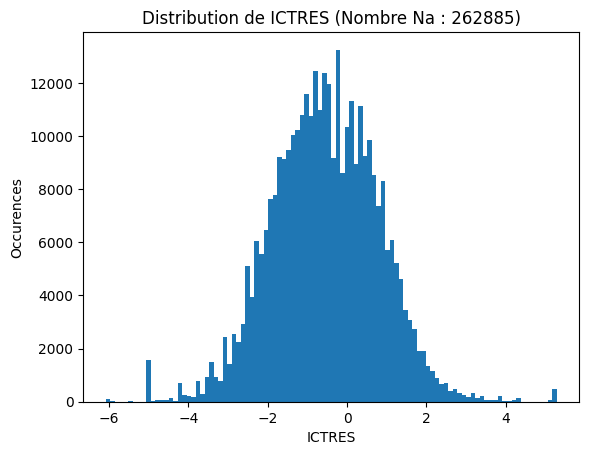

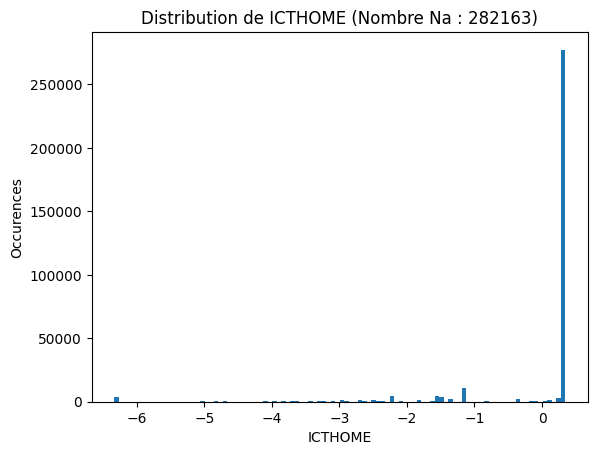

In [71]:
ictres,icthome=df['ICTRES'],df['ICTHOME']
ictres_na,icthome_na=ictres.isna().sum(),icthome.isna().sum()
# Distribution ICTRES
plt.hist(ictres,bins=100)
plt.xlabel('ICTRES')
plt.ylabel('Occurences')
plt.title('Distribution de ICTRES '+f'(Nombre Na : {ictres_na})')
plt.show()
# Distribution ICTHOME 
plt.hist(icthome,bins=100)
plt.xlabel('ICTHOME')
plt.ylabel('Occurences')
plt.title('Distribution de ICTHOME '+f'(Nombre Na : {icthome_na})')
plt.show()

In [72]:
# Nombre d'occurence des valeurs prises par ces deux variables 
ictres_count=ictres.value_counts()
icthome_count=icthome.value_counts()
ictres_count,icthome_count

(ICTRES
 -0.2035    2866
 -0.4979    2436
 -0.5542    1990
 -0.8053    1916
  0.1083    1429
            ... 
  4.2096       1
  4.2365       1
  4.2450       1
  4.2846       1
  4.3014       1
 Name: count, Length: 40459, dtype: int64,
 ICTHOME
  0.3346    274384
 -1.1402     11095
 -1.5118      3886
 -6.3292      3830
 -2.2168      2933
             ...  
 -4.4253         1
 -4.4221         1
 -4.4062         1
 -1.4106         1
 -6.2014         1
 Name: count, Length: 488, dtype: int64)

In [73]:
# Nombre de valeurs de ICTHOME qui apparaissent au moins 2900 fois
len(icthome_count[icthome_count>=2900])

5

In [74]:
# Part d'observations dont la valeur ICTHOME prend une des 5 valeurs les plus présente
p=round(icthome_count[icthome_count>=2900].sum()/icthome_count.sum()*100,2)
print(f'5 valeurs de la variables ICTHOME sont prises par {p} % des observations du dataset.')

5 valeurs de la variables ICTHOME sont prises par 89.31 % des observations du dataset.


Bien que les deux variables ICTRES et ICTHOME nous donnent accès à la même information, i.e l'accès un certains nombre d'appareils digitaux au sein du foyer, la variables ICTHOME est beaucoup moins pertinente. En effet, on voit que cette dernière contient beaucoup moins d'information. La variable ICTHOME est une variable qui prend des valeurs continues. Cependant, dans l'échantillon considéré, cette variable est principalement représentée par seulement 5 valeurs différentes ce qui est bien trop peu sur un échantillon de plus de 600 000 observations. 

#### 2. **Traitement des identifiants**

On vérifie que chaque identifiant présent dans le jeu de donnée est bien associé à une unique observation

In [75]:
id_count=data['id'].value_counts().sort_values(ascending=False)
id_count.head()

id
800001.0    1
800002.0    1
800003.0    1
800005.0    1
800006.0    1
Name: count, dtype: int64

#### 3. **Recodage des variables qualitatives**

L'un des objectifs de ce projet est d'expliquer la créativité des élèves à partir de plusieurs facteurs choisis précédemment. Pour ce faire, nous utiliserons certains modèles de régression notamment la régression linéaire. 

Il est donc primordial de recoder les variables qualitatives en variables quantitatives afin de pouvoir les considérer par la suite. 

Les seules variables qualitatives du dataset sont les variables : *gender*, *home_language*, *sport*, *work* et *household_care*

Recodage des variables

*gender*

In [76]:
data['gender'].nunique()

2

Cette variable est binaire, on peut donc la recoder en 0 pour les labels 'Male' et 1 pour les labels 'Female'

In [77]:
data['gender']=data['gender'].replace({'Male':0,'Female':1})

/tmp/ipykernel_104082/3507592353.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['gender']=data['gender'].replace({'Male':0,'Female':1})
/tmp/ipykernel_104082/3507592353.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data['gender']=data['gender'].replace({'Male':0,'Female':1})


*sport*

In [78]:
data['sport'].value_counts()

sport
No exercise or sports                                89333
10 or more times of exercising or sports per week    87532
2 times of exercising or sports per week             50158
4 times of exercising or sports per week             50120
5 times of exercising or sports per week             43740
6 times of exercising or sports per week             41083
3 times of exercising or sports per week             37127
8 times of exercising or sports per week             25585
1 time of exercising or sports per week              22161
7 times of exercising or sports per week             12717
9 times of exercising or sports per week              8251
Name: count, dtype: int64

La variable *sport* prend ses 11 valeurs distinctes (la fréquence d'activité sportive hebdomadaire). On peut recoder chaque label par la fréquence hebdomadaire d'activité sportive. 

In [79]:
data['sport']=data['sport'].str[:2].copy()
data['sport']=data['sport'].replace({'No':0})
data['sport']=data['sport'].astype(float)
data.head()

,id,gender,society,home_language,sport,work,household_care,digital_home,social,school_safety,...,parent_invol,school_support,creative_out,creative_at,math_reasoning,safety,climate_math,math_thinking,weight,score
0,800001.0,1,1.1112,Albanian,0.0,No work for pay,10 or more times of working in household or ca...,4.9507,-1.2280,-0.6386,...,NaN,NaN,NaN,4.1226,2.4031,1.1246,0.6387,2.4962,3.15874,3.25
1,800002.0,0,-3.0507,Albanian,NaN,NaN,NaN,-3.4930,1.3336,NaN,...,NaN,NaN,NaN,NaN,NaN,1.1246,NaN,NaN,4.34524,4.53
2,800003.0,0,-0.1867,Albanian,NaN,No work for pay,No work in household or care of family members,0.4307,NaN,-0.6386,...,NaN,NaN,NaN,NaN,NaN,0.8637,-0.8615,NaN,7.83860,8.95
3,800005.0,1,-3.2198,Albanian,10.0,No work for pay,10 or more times of working in household or ca...,-2.1392,0.9885,-0.6386,...,NaN,1.5382,1.4468,1.0191,0.3556,-0.7560,0.4426,-0.1216,8.49148,0.52
4,800006.0,1,-1.0548,Albanian,2.0,No work for pay,4 times of working in household or caring for ...,-0.5542,-1.2280,-0.6386,...,NaN,0.2241,1.8557,1.6583,-1.0257,1.1246,0.4029,0.7927,3.70957,19.33


*work*

In [80]:
data['work'].value_counts()

work
No work for pay                                 324912
2 times of working for pay per week              26020
10 or more times of working for pay per week     23328
1 time of working for pay per week               16840
4 times of working for pay per week              16594
5 times of working for pay per week              15512
3 times of working for pay per week              12913
6 times of working for pay per week              10726
8 times of working for pay per week               6152
7 times of working for pay per week               4515
9 times of working for pay per week               2630
Name: count, dtype: int64

De façon similaire :

In [81]:
data['work']=data['work'].str[:2].copy()
data['work']=data['work'].replace({'No':0})
data['work']=data['work'].astype(float)
data.head()

,id,gender,society,home_language,sport,work,household_care,digital_home,social,school_safety,...,parent_invol,school_support,creative_out,creative_at,math_reasoning,safety,climate_math,math_thinking,weight,score
0,800001.0,1,1.1112,Albanian,0.0,0.0,10 or more times of working in household or ca...,4.9507,-1.2280,-0.6386,...,NaN,NaN,NaN,4.1226,2.4031,1.1246,0.6387,2.4962,3.15874,3.25
1,800002.0,0,-3.0507,Albanian,NaN,NaN,NaN,-3.4930,1.3336,NaN,...,NaN,NaN,NaN,NaN,NaN,1.1246,NaN,NaN,4.34524,4.53
2,800003.0,0,-0.1867,Albanian,NaN,0.0,No work in household or care of family members,0.4307,NaN,-0.6386,...,NaN,NaN,NaN,NaN,NaN,0.8637,-0.8615,NaN,7.83860,8.95
3,800005.0,1,-3.2198,Albanian,10.0,0.0,10 or more times of working in household or ca...,-2.1392,0.9885,-0.6386,...,NaN,1.5382,1.4468,1.0191,0.3556,-0.7560,0.4426,-0.1216,8.49148,0.52
4,800006.0,1,-1.0548,Albanian,2.0,0.0,4 times of working in household or caring for ...,-0.5542,-1.2280,-0.6386,...,NaN,0.2241,1.8557,1.6583,-1.0257,1.1246,0.4029,0.7927,3.70957,19.33


*household_care*

In [82]:
data['household_care'].value_counts()

household_care
10 or more times of working in household or caring for family members per week    126643
5 times of working in household or caring for family members per week              53141
No work in household or care of family members                                     52709
4 times of working in household or caring for family members per week              41193
2 times of working in household or caring for family members per week              40778
6 times of working in household or caring for family members per week              37511
3 times of working in household or caring for family members per week              32650
8 times of working in household or caring for family members per week              28560
1 time of working in household or caring for family members per week               20839
7 times of working in household or caring for family members per week              19329
9 times of working in household or caring for family members per week              14425
Name: 

De façon analogue

In [83]:
data['household_care']=data['household_care'].str[:2].copy()
data['household_care']=data['household_care'].replace({'No':0})
data['household_care']=data['household_care'].astype(float)
data.head()

,id,gender,society,home_language,sport,work,household_care,digital_home,social,school_safety,...,parent_invol,school_support,creative_out,creative_at,math_reasoning,safety,climate_math,math_thinking,weight,score
0,800001.0,1,1.1112,Albanian,0.0,0.0,10.0,4.9507,-1.2280,-0.6386,...,NaN,NaN,NaN,4.1226,2.4031,1.1246,0.6387,2.4962,3.15874,3.25
1,800002.0,0,-3.0507,Albanian,NaN,NaN,NaN,-3.4930,1.3336,NaN,...,NaN,NaN,NaN,NaN,NaN,1.1246,NaN,NaN,4.34524,4.53
2,800003.0,0,-0.1867,Albanian,NaN,0.0,0.0,0.4307,NaN,-0.6386,...,NaN,NaN,NaN,NaN,NaN,0.8637,-0.8615,NaN,7.83860,8.95
3,800005.0,1,-3.2198,Albanian,10.0,0.0,10.0,-2.1392,0.9885,-0.6386,...,NaN,1.5382,1.4468,1.0191,0.3556,-0.7560,0.4426,-0.1216,8.49148,0.52
4,800006.0,1,-1.0548,Albanian,2.0,0.0,4.0,-0.5542,-1.2280,-0.6386,...,NaN,0.2241,1.8557,1.6583,-1.0257,1.1246,0.4029,0.7927,3.70957,19.33


On vérifie le type de chaque variable afin qu'elles puissent être utilisées dans notre régression.

In [84]:
#Type des variables
data.dtypes

id                  float64
gender             category
society            category
home_language      category
sport               float64
work                float64
household_care      float64
digital_home       category
social             category
school_safety      category
family_support     category
teacher_support    category
parent_invol       category
school_support     category
creative_out       category
creative_at        category
math_reasoning     category
safety             category
climate_math       category
math_thinking      category
weight              float64
score               float64
dtype: object

Toutes les variables sont catégorielles. Afin de pouvoir effectuer une régression par la suite il est nécessaire de les convertir en variables numériques. 

In [85]:
# Convertir toutes les variables en numérique (sauf id et home_language)
for col in data.columns:
    if col != 'id' and col != 'home_language':
        data[col] = pd.to_numeric(data[col], errors='coerce')

#### 4. **Traitement des valeurs manquantes**

Le traitement des valeurs manquantes est primordial. En effet, une valeur manquante peut provenir d'une erreur de saisie comme elle peut être volontaire. 

Une première partie s'intéresse à la distribution des valeurs manquantes au sein du dataset ainsi qu'à leurs sources notamment au travers d'un test MCAR qui permet d'évaluer si les données manquantes sont complètement aléatoires. 

Une seconde partie permettra en conséquence de traiter ces valeurs manquantes de deux façons différentes. 

##### 4.1 **Distribution des valeurs manquantes et test MCAR**


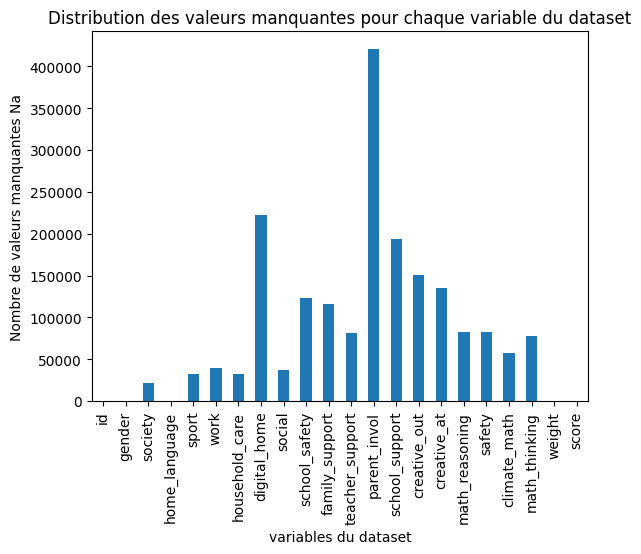

In [86]:
### Distribution des Na ### 
data_count_na=data.isna().sum()
data_count_na.plot(kind='bar')
plt.xlabel('variables du dataset')
plt.ylabel('Nombre de valeurs manquantes Na')
plt.title('Distribution des valeurs manquantes pour chaque variable du dataset')
plt.show()

La variable parent_invol contient beaucoup trop de valeurs manquantes. Cela vient du fait qu'il s'agit de la seule variable du datatset *data* qui provient du questionnaire donné aux parents de chaque élève et auquel moins de 100 000 d'entre eux sur 600 000 ont répondu. 

Dans un premier temps, nous travaillerons sans cette variable afin de garder un échantillon le plus gros possible. 

In [87]:
#Suppression variable parent_invol du dataset
data=data.drop(columns=['parent_invol'])

On remarque que la variable digital_home présente également une proportion importante de valeurs manquantes. Cette variable étant centrale pour notre problématique, nous ne pouvons ni la supprimer, ni supprimer les lignes concernées sinon cela entraînerait une perte trop importante de données et un biais de sélection majeur. 

Il est donc nécessaire de savoir si l'absence de réponse est corrélée aux caractéristiques des individus. Si l'absence de réponse n'est pas aléatoire, une imputations par la moyenne ou la médiane ne serait pas adaptée car elle ne préserverait pas les relations entre les variables. 

Ainsi, afin de tester si les données sont MCAR (Missing Completely At Random), nous comparons les moyennes des autres variables entre le groupe d'élèves ayant renseigné digital_home et celui ne l'ayant pas renseigné. 
Des différences significatives indiqueraient que les valeurs manquantes dépendraient d'autres caractéristiques observables et justifieront l'utilisation d'une méthode d'imputation plus sophistiquée. 

On effectue le test seulement sur ces 7 variables qui présentent peu de valeurs manquantes et sont représentatives du profil socio-économique des élèves.

In [88]:
#Test MCAR
print("="*60)
print("TEST MCAR - digital_home")
print("="*60)

has_digital = data['digital_home'].notna()
group_with = data[has_digital]
group_without = data[~has_digital]

print(f"\nAvec digital_home: {len(group_with):,} obs")
print(f"Sans digital_home: {len(group_without):,} obs\n")

test_vars = ['society', 'sport', 'work', 'household_care', 'creative_out', 'gender','social']

results = []
for var in test_vars:
    present = group_with[var].dropna()
    missing = group_without[var].dropna()
    
    if len(present) > 100 and len(missing) > 100:
        _, p = ttest_ind(present, missing)
        diff = present.mean() - missing.mean()
        
        results.append({
            'Variable': var,
            'Différence': f"{diff:.3f}",
            'p-value': f"{p:.4f}",
            'Signif': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'NS'
        })

import pandas as pd
print(pd.DataFrame(results).to_string(index=False))

nb_sig = sum(1 for r in results if r['Signif'] != 'NS')
print(f"\n{nb_sig}/{len(results)} variables significatives → {'Pas MCAR' if nb_sig > 0 else 'MCAR possible'}") 

TEST MCAR - digital_home

Avec digital_home: 277,584 obs
Sans digital_home: 222,259 obs

      Variable Différence p-value Signif
       society     -0.369  0.0000    ***
         sport      0.125  0.0000    ***
          work      0.710  0.0000    ***
household_care      0.162  0.0000    ***
  creative_out      0.296  0.0000    ***
        gender      0.010  0.0000    ***
        social      0.214  0.0000    ***

7/7 variables significatives → Pas MCAR


On en conclut que les données ne sont pas MCAR sur ces variables, ainsi la probabilité qu'une valeur soit manquante dépend d'autres variables observées. 

Nous aurons donc recours à un modèle de Random Forest dans la partie dédiée au traitement des valeurs manquantes afin d'imputer les valeurs manquantes.


Nous pouvons analyser la distribution des valeurs manquantes selon le pays de l'élève.

In [89]:
data['country']=df['CNT']
data['country']

0         Albania
1         Albania
2         Albania
3         Albania
4         Albania
           ...   
499838      Spain
499839      Spain
499840      Spain
499841      Spain
499842      Spain
Name: country, Length: 499843, dtype: category
Categories (80, object): ['Albania', 'Argentina', 'Australia', 'Austria', ..., 'United States', 'Uruguay', 'Uzbekistan', 'Viet Nam']

/tmp/ipykernel_104082/3062385878.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='X',y='y',data=d,palette='mako')


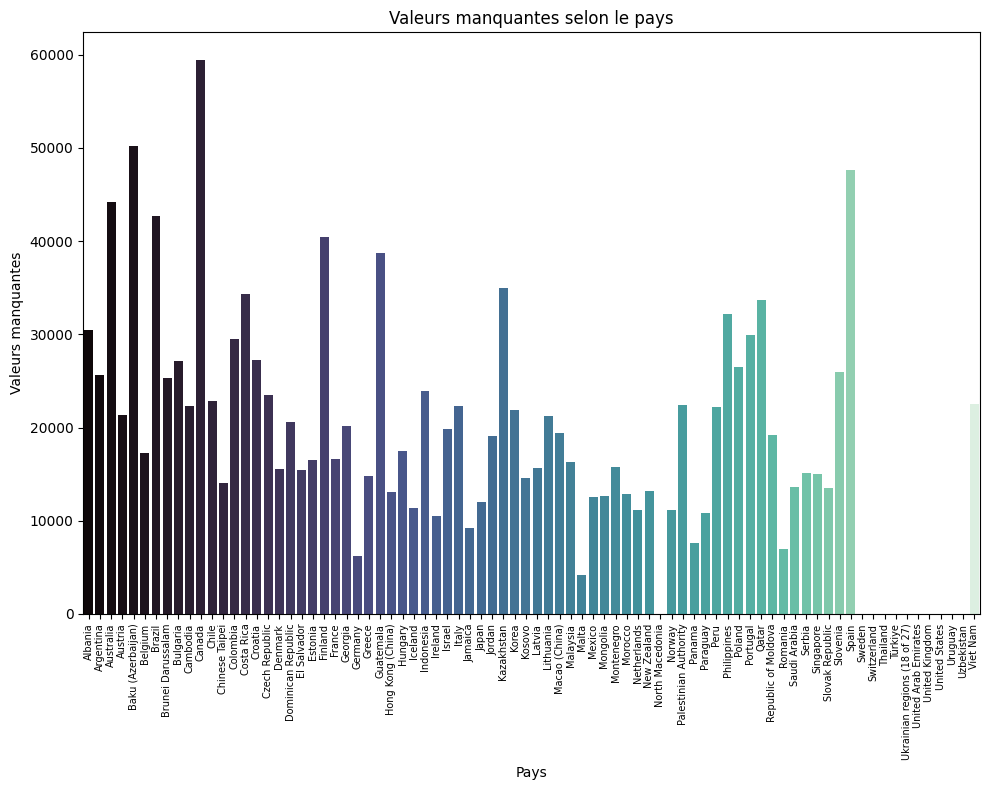

In [90]:
import seaborn as sns

X,y = data['country'].unique(),[]
for country in X:
    y.append(data[data['country']==country].isnull().sum().sum())
d=pd.DataFrame({'X':X,'y':y})


plt.figure(figsize=(10,8))
sns.barplot(x='X',y='y',data=d,palette='mako')
plt.title('Valeurs manquantes selon le pays')
plt.xlabel('Pays')
plt.ylabel('Valeurs manquantes')
plt.xticks(rotation=90,fontsize=7)
plt.tight_layout()
plt.show()

L'analyse des valeurs manquantes met en avant des disparités selon le pays de l'élève. Cependant, puisque le graphique est difficilement interprétable dû à un grand nombre de pays, nous faisons un second graphique qui se restreint aux 15 pays ayant le plus de valeurs manquantes. 

/tmp/ipykernel_104082/3855656231.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='y', y='X', data=d_top, palette='mako', orient='h')


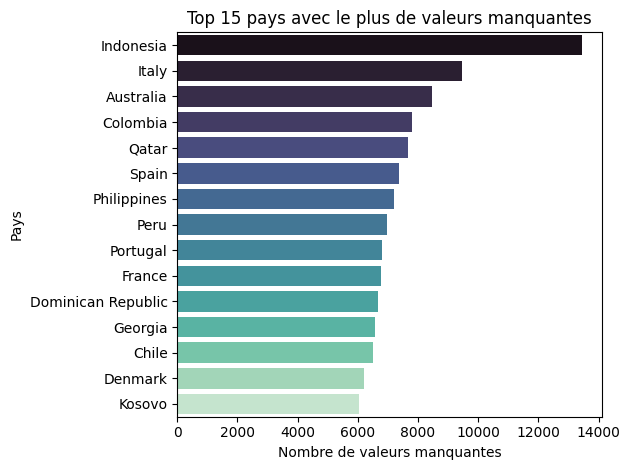

In [101]:
#Trier par nombre de valeurs manquantes (décroissant)
d_sorted = d.sort_values('y', ascending=False)

#Restriction au top 15
top_n = 15
d_top = d_sorted.head(top_n).copy()

#Convertir en string pour éviter les catégories fantômes
d_top['X'] = d_top['X'].astype(str)

#Graphique
sns.barplot(x='y', y='X', data=d_top, palette='mako', orient='h')
plt.title(f'Top {top_n} pays avec le plus de valeurs manquantes')
plt.xlabel('Nombre de valeurs manquantes')
plt.ylabel('Pays')
plt.tight_layout()
plt.show()

Les élèves indonésiens présentent un nombre de valeurs manquantes très élevé par rapport à la majorité des autres pays avec environ 140 000 NA. L'Italie et lAustralie Unis ont également un taux de non réponse proche de l'Espagne. Ces disparités suggèrent de possibles difficultés d'accès à l'information ou de collecte de données. Cette observation est cohérente avec notre problématique sur l'équilibre entre rareté et accès à l'information. 

Nous pouvons nous concentrer sur l'analyse des valeurs manquantes uniquement sur la variable digital_home pour observer de possibles différences d'accès au numérique. 
Nous nous concentrons de nouveaux sur les 15 pays principaux afin d'obtenir un résultat lisible.

/tmp/ipykernel_104082/173152831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='y', y='X', data=d_top, palette='mako', orient='h',


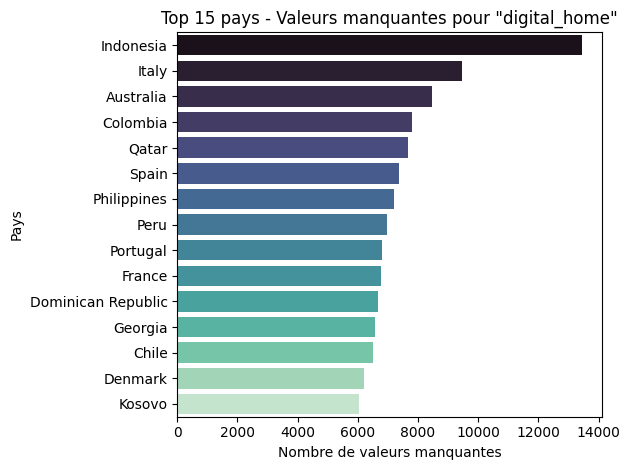

In [102]:
X, y = data['country'].unique(), []
for country in X:
    y.append(data[data['country']==country].isnull().sum()['digital_home'])

d = pd.DataFrame({'X': X, 'y': y})

#Trier et garder seulement le top 15
d_sorted = d.sort_values('y', ascending=False)
d_top = d_sorted.head(15)

#Graphique
sns.barplot(x='y', y='X', data=d_top, palette='mako', orient='h',
            order=d_top['X'].values)
plt.title('Top 15 pays - Valeurs manquantes pour "digital_home"')
plt.xlabel('Nombre de valeurs manquantes')
plt.ylabel('Pays')
plt.tight_layout()
plt.show()


On retrouve de nouveau l'Indonésie en tête, nous pouvons donc nous interroger sur des différences culturelles ou économique des élèves indonésiens qui pourraient impacter la pensée créative de ces derniers. Les pays suivants sont identiques.

Les valeurs manquantes pour chaque variable tout pays confondues sont :

In [103]:
data.isnull().sum()

id                      0
gender                 74
society             21119
home_language           0
sport               32036
work                39701
household_care      32065
digital_home       222259
social              37675
school_safety      122778
family_support     115878
teacher_support     80847
school_support     193530
creative_out       150592
creative_at        134742
math_reasoning      82309
safety              83127
climate_math        56975
math_thinking       77891
weight                  0
score                   0
country                 0
dtype: int64

Si l'ont retire l'Indonésie et l'Italie qui sont les pays ayant le plus de valeurs manquantes :

In [105]:
data[(data['country']!='Indonesia') & (data['country']!='Italy')].isnull().sum()

id                      0
gender                 74
society             20846
home_language           0
sport               31601
work                39211
household_care      31614
digital_home       199357
social              37221
school_safety      122338
family_support     113931
teacher_support     79828
school_support     186068
creative_out       147148
creative_at        131956
math_reasoning      80837
safety              82709
climate_math        56082
math_thinking       76600
weight                  0
score                   0
country                 0
dtype: int64

L'Espagne et le Canada concentrent une part importante des valeurs manquantes du dataset, cependant les valeurs manquantes restent distribuées de manière homogène parmi le reste des autres pays. Retirer l'Espagne et le Canada de notre analyse ne résoudrait pas le problème. Il sera donc nécessaire de procéder à une imputation des données sur l'ensemble du data set. 

##### 4.2.1 **Imputation des valeurs manquantes**

Comme expliqué dans la partie précédente, nous allons recourir à un modèle de Random Forest afin d'imputer les valeurs manquantes de notre dataset grâce à la méthode des **MissForest**. Cet algorithme utilise des forêts aléatoires pour prédire les valeurs manquantes de chaque variable en fonction des autres variables du dataset. Cette approche permet de capturer les relations complexes entre variables ce qui est davantage adapté pour les données non MCAR plutôt qu'une imputation par la moyenne ou la médiane.

La méthode des MissForest présente plusieurs avantages notamment : 
- imputation pour variables numériques et catégorielles
- gestion des valeurs aberrantes donc pas de mise à l'échelle nécessaire
- capture assez bien les relations non linéaires entre variables 
- performant dans les cas de multicolinéarité

On importe les packages nécessaires :

In [106]:
!pip install missforest
!pip install lightgbm

**Remarque** : On importe le package lightgbm car les versions les plus récentes de MissForest utilisent en interne un LightGbm afin d'optimiser les différents algorithmes et rendre le MissForest plus rapide.  

In [107]:
from sklearn.model_selection import train_test_split
from missforest.missforest import MissForest

# On retire les colonnes home_language et country car il s'agit de variables de type category sans valeurs manquantes
data_for_forest=data.drop(columns=['home_language','country'])

# Split dataset en train et en test.
train, test = train_test_split(data_for_forest, test_size=0.3, shuffle=True, random_state=42)

va = ['household_care','sport','work']

# Importation du MissForest
mf = MissForest(categorical=va,verbose=True)

# Entrainement du modèle 
data_clear= mf.fit_transform(train)

# Bases prédites
train_pred=mf.transform(train)
test_pred=mf.transform(test)

 80%|████████  | 4/5 [00:04<00:01,  1.01s/it]


On applique la méthode des MissForest au dataset complet "data" à partir du modèle entraîné "mf".

In [108]:
data_c=mf.transform(data_for_forest)

100%|██████████| 5/5 [00:12<00:00,  2.58s/it]


In [109]:
data

,id,gender,society,home_language,sport,work,household_care,digital_home,social,school_safety,...,school_support,creative_out,creative_at,math_reasoning,safety,climate_math,math_thinking,weight,score,country
0,800001.0,1.0,1.1112,Albanian,0.0,0.0,10.0,4.9507,-1.2280,-0.6386,...,NaN,NaN,4.1226,2.4031,1.1246,0.6387,2.4962,3.15874,3.25,Albania
1,800002.0,0.0,-3.0507,Albanian,NaN,NaN,NaN,-3.4930,1.3336,NaN,...,NaN,NaN,NaN,NaN,1.1246,NaN,NaN,4.34524,4.53,Albania
2,800003.0,0.0,-0.1867,Albanian,NaN,0.0,0.0,0.4307,NaN,-0.6386,...,NaN,NaN,NaN,NaN,0.8637,-0.8615,NaN,7.83860,8.95,Albania
3,800005.0,1.0,-3.2198,Albanian,10.0,0.0,10.0,-2.1392,0.9885,-0.6386,...,1.5382,1.4468,1.0191,0.3556,-0.7560,0.4426,-0.1216,8.49148,0.52,Albania
4,800006.0,1.0,-1.0548,Albanian,2.0,0.0,4.0,-0.5542,-1.2280,-0.6386,...,0.2241,1.8557,1.6583,-1.0257,1.1246,0.4029,0.7927,3.70957,19.33,Albania
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499838,86007488.0,1.0,-2.7487,Uzbek,4.0,0.0,10.0,NaN,-1.2280,-0.6386,...,NaN,NaN,NaN,-2.2416,0.6942,1.7598,2.5872,69.40366,13.07,Spain
499839,86007489.0,0.0,-0.2024,Uzbek,4.0,0.0,10.0,NaN,-1.2280,-0.6386,...,NaN,NaN,NaN,NaN,-0.7560,NaN,NaN,63.18910,3.52,Spain
499840,86007490.0,0.0,-2.0506,Uzbek,10.0,0.0,5.0,NaN,-0.5168,-0.6386,...,NaN,0.6097,0.4911,0.6856,0.4417,0.3521,0.9323,65.47339,13.00,Spain
499841,86007491.0,1.0,-0.1290,Uzbek,9.0,0.0,10.0,NaN,-1.2280,-0.6386,...,NaN,NaN,NaN,0.3322,1.1246,1.7598,1.3822,66.15595,11.83,Spain


Notre dataset après imputation qui sera utilisé pour la suite de cette analyse :

In [35]:
data_c

,id,score,weight,gender,society,sport,household_care,social,work,climate_math,math_thinking,teacher_support,math_reasoning,safety,family_support,school_safety,creative_at,creative_out,school_support,digital_home
0,800001.0,3.25,3.15874,1.0,1.1112,0.0,10.0,-1.228000,0.0,0.638700,2.496200,1.555800,2.403100,1.1246,1.835500,-0.638600,4.122600,3.397848,1.103397,4.950700
1,800002.0,4.53,4.34524,0.0,-3.0507,0.0,10.0,1.333600,0.0,-0.383193,0.259682,0.151745,0.175727,1.1246,-0.139283,0.554612,0.365375,0.300301,-0.200880,-3.493000
2,800003.0,8.95,7.83860,0.0,-0.1867,0.0,0.0,-0.441627,0.0,-0.861500,0.160204,0.050804,0.147283,0.8637,-0.091043,-0.638600,0.311948,0.164481,-0.155093,0.430700
3,800005.0,0.52,8.49148,1.0,-3.2198,10.0,10.0,0.988500,0.0,0.442600,-0.121600,1.555800,0.355600,-0.7560,-0.746800,-0.638600,1.019100,1.446800,1.538200,-2.139200
4,800006.0,19.33,3.70957,1.0,-1.0548,2.0,4.0,-1.228000,0.0,0.402900,0.792700,0.147500,-1.025700,1.1246,-0.512200,-0.638600,1.658300,1.855700,0.224100,-0.554200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499838,86007488.0,13.07,69.40366,1.0,-2.7487,4.0,10.0,-1.228000,0.0,1.759800,2.587200,1.555800,-2.241600,0.6942,1.594100,-0.638600,0.138548,0.257956,0.738150,-1.349356
499839,86007489.0,3.52,63.18910,0.0,-0.2024,4.0,10.0,-1.228000,0.0,0.288883,0.356419,0.263885,0.223416,-0.7560,-0.024479,-0.638600,0.320883,0.352505,-0.122735,-1.001333
499840,86007490.0,13.00,65.47339,0.0,-2.0506,10.0,5.0,-0.516800,0.0,0.352100,0.932300,0.821100,0.685600,0.4417,-1.029600,-0.638600,0.491100,0.609700,-0.272649,-1.181412
499841,86007491.0,11.83,66.15595,1.0,-0.1290,9.0,10.0,-1.228000,0.0,1.759800,1.382200,1.555800,0.332200,1.1246,0.976214,-0.638600,0.350674,0.499383,0.628899,-0.290847


On vérifie qu'il n'y a plus de valeurs manquantes : 

In [110]:
data_c.isnull().sum().sum()

np.int64(0)

##### 5 **Création d'un dataset pondéré**

La variable *weight* permet de pondérer chaque observation du jeu de données afin de rendre l'échantillon plus représentatif. Ces poids permettent de compenser l'absence d'observations de sous-groupes sous représentées dans l'échantillon. 
L'idée par la suite est de comparer les résultats avec et sans pondération et de voir si les résultats sont plus intéressants. 

Avant de créer le dataset pondéré, vérifions quelques statistiques sur la variable *weight* afin d'éviter d'introduire plus de biais dans la suite. 

In [111]:
data_c['weight'].describe()

count    499843.000000
mean         39.099493
std          84.071554
min           1.000000
25%           4.446890
50%          11.339320
75%          37.248030
max        2371.650000
Name: weight, dtype: float64

In [112]:
len(data_c[data_c['weight']<=150])/len(data_c['weight'])*100

94.04052872601997

On voit que 95% des observations ont un poids inférieur à 150. Fixons le seuil maximal à cette valeur et tronquons les poids supérieurs à ce seuil. La troncature des poids extrêmes vise à limiter l'effet de certaines observations sur l'ensemble des mesures statistiques. En effet, une observation avec un poids trop élevé aura une influence beaucoup trop forte sur les mesures statistiques et biaisera en conséquence les résultats de nos modèles. 

In [113]:
data_c_pond=data_c.copy()
data_c_pond.loc[data_c_pond['weight']>150,'weight']=150

On finalise maintenant le nouveau dataset en arrondissant au préalable les poids : 

Data Set prenant en compte les poids arrondis : 

In [114]:
# On arrondit le poids pour créer un nombre entier de répétitions
replicate_count = np.round(data_c['weight']).astype(int)

# Réplication des lignes
data_c_pond = data_c_pond.loc[data_c_pond.index.repeat(replicate_count)].reset_index(drop=True)


In [115]:
data_c_pond.shape

(19538218, 20)

# **III. Statistiques descriptives sur le jeu de données**


L'objectif de cette partie est de se familiariser avec le dataset utilisé au travers de statistiques descriptives. 

#### **1. Vision globale de notre data set**

**1.1 Sans pondération**

In [116]:
data_c.describe(include='all')

,id,score,weight,gender,society,sport,household_care,social,work,climate_math,math_thinking,teacher_support,math_reasoning,safety,family_support,school_safety,creative_at,creative_out,school_support,digital_home
count,4.998430e+05,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000,499843.000000
mean,4.224687e+07,28.453006,39.099493,0.498292,-0.290879,4.325308,5.855829,-0.271670,1.338498,0.006119,0.183601,0.096278,0.131412,-0.095539,-0.008633,-0.083163,0.206658,0.264605,0.027053,-0.523131
std,2.462631e+07,12.011678,84.071554,0.499970,1.083916,3.591487,3.573808,1.020433,2.711244,0.934679,0.976280,1.061628,0.963319,0.932485,0.953526,0.894881,0.967711,0.998720,0.864888,1.053788
min,8.000010e+05,0.150000,1.000000,0.000000,-6.840700,0.000000,0.000000,-1.336177,0.000000,-2.582495,-2.389472,-3.314841,-2.745300,-2.788600,-3.869500,-1.414938,-2.075600,-0.820500,-2.859900,-6.660831
25%,2.080555e+07,19.190000,4.446890,0.000000,-0.998900,1.000000,3.000000,-1.228000,0.000000,-0.526000,-0.338500,-0.563500,-0.375700,-0.756000,-0.594400,-0.638600,-0.287114,-0.677900,-0.397683,-1.012344
50%,3.981541e+07,28.950000,11.339320,0.000000,-0.185700,4.000000,6.000000,-0.391000,0.000000,-0.078400,0.186800,-0.100200,0.110498,-0.091800,-0.087061,-0.638600,0.186744,0.130300,-0.055000,-0.497900
75%,6.420335e+07,37.970000,37.248030,1.000000,0.561200,7.000000,10.000000,0.488300,1.000000,0.501219,0.656400,0.821100,0.486700,1.124600,0.447017,0.413900,0.600300,0.804500,0.376400,-0.086838
max,8.600749e+07,58.330000,2371.650000,1.037382,7.380000,10.000000,10.000000,4.693900,10.000000,2.225800,2.836921,1.814419,3.270500,1.168700,22.270797,3.649200,8.629000,4.799400,29.304680,6.537946


La fonction describe nous donne un premier aperçu de notre data set et de la répartition des données qui compte environ 450 000 élèves. La répartition des genres est équilibrée au sein de l'échantillon avec 49% de filles. 

Les statistiques descriptives révèlent une hétérogénéité importante dans l'accès à l'information (digital_home, society) au sein de l'échantillon avec des écarts-types importants. L'échantillon est légèrement défavorisé avec des moyennes négatives sur ces variables. Les moyennes des variables de créativité étant positives, les élèves participent en moyenne de manière légèrement régulière aux activités créatives et davantage à l’extérieur de l'école. 

Le minimum et le maximum des valeurs prises par chaque variable sont relativement éloignés ce qui est favorable pour l'estimation des paramètres de notre régression et ainsi tester l'impact de la rareté et l'accès à l'information sur la pensée créative. Les moyennes de soutient familial et par le corps professoral sont proches de la moyenne internationale. 

**1.2 Avec pondération**

In [117]:
data_c_pond.describe()

,id,score,weight,gender,society,sport,household_care,social,work,climate_math,math_thinking,teacher_support,math_reasoning,safety,family_support,school_safety,creative_at,creative_out,school_support,digital_home
count,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07,1.953822e+07
mean,3.976746e+07,2.454241e+01,1.011343e+02,5.051576e-01,-8.258579e-01,4.349073e+00,5.923885e+00,-2.135979e-01,1.697750e+00,-2.605925e-02,2.732228e-01,1.706409e-01,2.111319e-01,-2.339855e-01,-1.120570e-01,-9.214023e-02,3.379520e-01,4.470562e-01,-9.093131e-02,-1.057683e+00
std,2.155783e+07,1.246850e+01,5.400231e+01,4.999659e-01,1.219751e+00,3.678046e+00,3.649153e+00,1.058935e+00,3.030417e+00,9.353169e-01,1.001245e+00,1.056638e+00,9.806935e-01,9.226204e-01,9.880314e-01,8.907644e-01,9.883144e-01,1.030528e+00,8.731538e-01,1.172432e+00
min,8.000010e+05,1.500000e-01,1.000000e+00,0.000000e+00,-6.840700e+00,0.000000e+00,0.000000e+00,-1.336177e+00,0.000000e+00,-2.582495e+00,-2.389472e+00,-3.314841e+00,-2.745300e+00,-2.788600e+00,-3.869500e+00,-1.414938e+00,-2.075600e+00,-8.205000e-01,-2.859900e+00,-6.660831e+00
25%,2.500292e+07,1.448000e+01,5.191173e+01,0.000000e+00,-1.694600e+00,1.000000e+00,3.000000e+00,-1.228000e+00,0.000000e+00,-5.532000e-01,-2.763000e-01,-5.635000e-01,-3.077551e-01,-7.560000e-01,-7.034000e-01,-6.386000e-01,-1.145000e-01,-2.230000e-01,-5.411000e-01,-1.859800e+00
50%,3.601264e+07,2.388000e+01,1.280272e+02,1.000000e+00,-7.944000e-01,4.000000e+00,6.000000e+00,-3.413719e-01,0.000000e+00,-9.030000e-02,2.281000e-01,4.369799e-02,1.931000e-01,-6.440460e-01,-1.465695e-01,-6.386000e-01,2.733000e-01,2.761000e-01,-1.310967e-01,-1.005500e+00
75%,6.040627e+07,3.417000e+01,1.500000e+02,1.000000e+00,1.220000e-01,8.000000e+00,1.000000e+01,5.869000e-01,2.000000e+00,4.768000e-01,7.936000e-01,1.555800e+00,5.637000e-01,4.938000e-01,3.370000e-01,4.437000e-01,7.860000e-01,1.034500e+00,2.222000e-01,-3.390000e-01
max,8.600749e+07,5.833000e+01,1.500000e+02,1.037382e+00,7.380000e+00,1.000000e+01,1.000000e+01,4.693900e+00,1.000000e+01,2.225800e+00,2.836921e+00,1.814419e+00,3.270500e+00,1.168700e+00,2.227080e+01,3.649200e+00,8.629000e+00,4.799400e+00,2.930468e+01,6.537946e+00


En pondérant chaque observation par le poids associé, on constate de légères différences avec les statistiques du dataset précédent. 
D'abord, les écarts-types ont légèrement augmenté mais pas de façon conséquente. 

Ensuite, on constate que la répartition des variables *safety*, *teacher_support*, *society* et *digital_home* ont changé de manière non négligeable. Il y a eu un décalage de la répartition vers le bas pour les variables *digital_home*, *safety* et *society*, autrement dit les valeurs les plus basses sont plus représentées au sein de l'échantillon pour ces variables. Par exemple pour la variable *digital_home*, dans le premier dataset sans pondération, 75% des observations ont un *digital_home* inférieur à -0.08 tandis que dans le second dataset, 75% des observations ont un *digital_home* inférieur à -0.33. Une partie de la distribution s'est donc déplacée vers les plus basses valeurs. 

A l'inverse, la variable *teacher_support* a subi un décalage de sa distribution vers le haut, i.e que là où 75% des observations avaient un *teacher_support* dans le premier cas, la valeur associée au troisième quartile est passée à 1.55. On a donc une partie de la distribution qui s'est déplacée vers les plus hautes valeurs. 



#### **2. Premières variables de créativité**

**2.1 Premières variables de créativité**

Dans cette partie, on s'intéresse aux premières variables de créativité à savoir creative_out et creative_at qui représentent la fréquence de pratique à des activités créatives. Nous nous intéresserons à la deuxième variable de créativité score dans une seconde partie.

**2.1.1 Sans pondération**

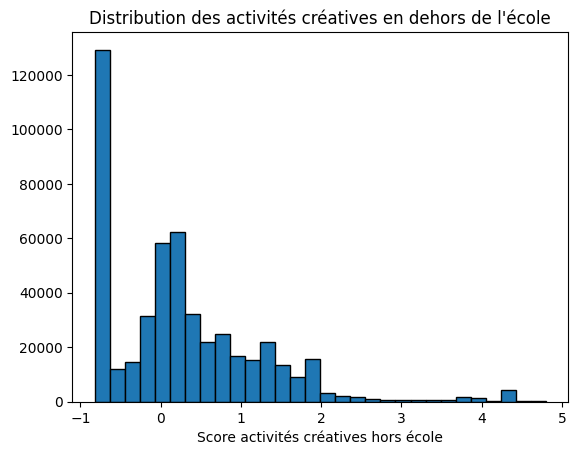

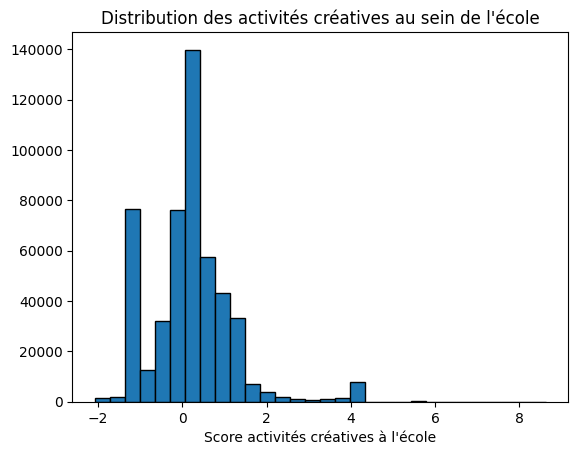

In [123]:
plt.hist(data_c['creative_out'], bins=30, edgecolor='black')
plt.title("Distribution des activités créatives en dehors de l'école")
plt.xlabel('Score activités créatives hors école')
plt.show()

plt.hist(data_c['creative_at'], bins=30, edgecolor='black')
plt.title("Distribution des activités créatives au sein de l'école")
plt.xlabel('Score activités créatives à l\'école')
plt.show()

La variable creative_out présente une très forte asymétrie à gauche avec un grand nombre d'individus en -1, indiquant qu'un grand nombre d'élèves participent peu aux activités créatives en dehors de l'école. Des niveaux faibles de créativité sont récurrents. La variable est plutôt dispersée indiquant une forte variabilité entre les élèves. 

Creative_at est plus normalement distribuée avec un pic juste après 0. La majorité des élèves participent légèrement plus que la moyenne internationale aux activités créatives proposées par l'école. Cette variable est moins dispersée que la précédente. 

Cette dispersion de la créativité suggère que la participation aux activités dépend de multiples facteurs éducatifs et sociaux. De plus elle n'est pas répartie uniformément au sein de la population. 

On remarque que les 2 variables de créativité ne sont pas distribuées de la même manière nous pouvons donc approfondir cette comparaison à l'aide de box plot.

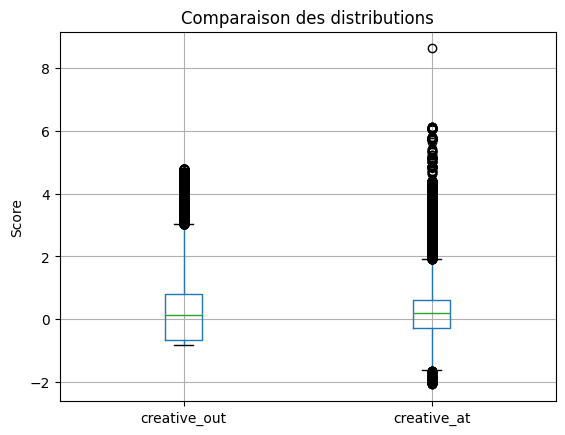

In [119]:
#Box plot comparaison des distributions des variables de créativité
data_c[['creative_out', 'creative_at']].boxplot()
plt.title('Comparaison des distributions')
plt.ylabel('Score')
plt.show()

Créative_at est plus concentrée autour de sa médiane légèrement supérieure à la moyenne internationale de créativité. Cependant, elles dispose d'un grand nombre de valeurs aberrantes majoritairement positives, plus que creative_out. Ainsi, l'école homogénéise davantage les pratiques créatives. La plus grande dispersion de la créativité en dehors de l'école suggère que l'accès aux ressources externes crée des inégalités plus marquées qu'à l'école.

**2.1.2 Avec pondération**

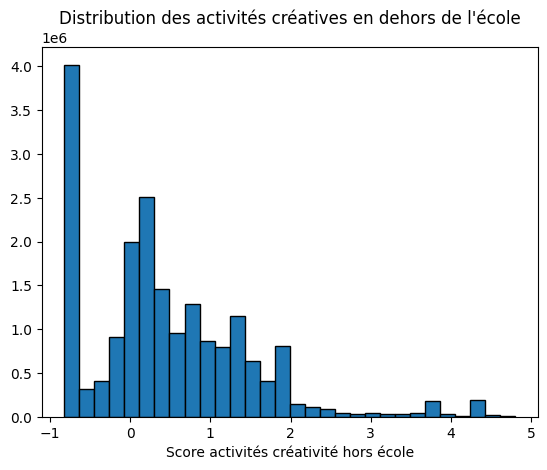

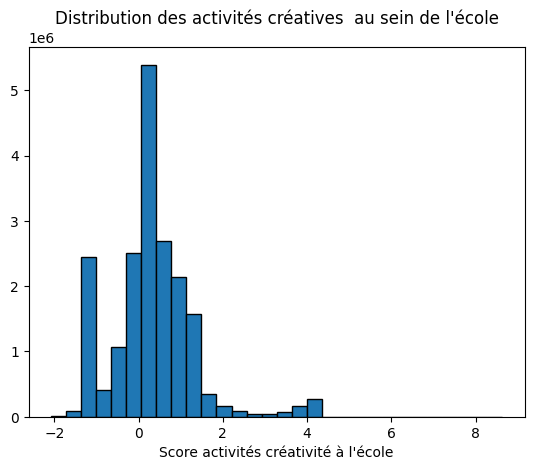

In [124]:
plt.hist(data_c_pond['creative_out'], bins=30, edgecolor='black')
plt.title("Distribution des activités créatives en dehors de l'école")
plt.xlabel('Score activités créativité hors école')
plt.show()

plt.hist(data_c_pond['creative_at'], bins=30, edgecolor='black')
plt.title("Distribution des activités créatives  au sein de l'école")
plt.xlabel('Score activités créativité à l\'école')
plt.show()

On constate que globalement, les distributions sont assez similaires à celles obtenues dans le cas non pondéré. Ces deux représentations confirment ce qui a été dit en première partie : creative_out et creative_at n'ont pas vu leur distribution grandement changer.  

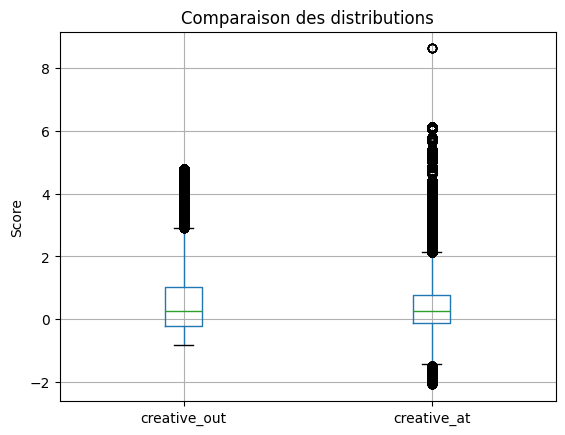

In [125]:
#Box plot comparaison des distributions des variables de créativité
data_c_pond[['creative_out', 'creative_at']].boxplot()
plt.title('Comparaison des distributions')
plt.ylabel('Score')
plt.show()

Là encore, les conclusions sont les mêmes que dans le cas non pondéré puisqu'il n'y a pas de majeure différence entre les distributions. 

**2.1 Deuxième variable de créativité (avec pondération)**

Dans cette partie, on s'intéresse à la deuxième variable de créativité à savoir score. Nous ne nous intéresserons ici qu'au cas avec pondération. 

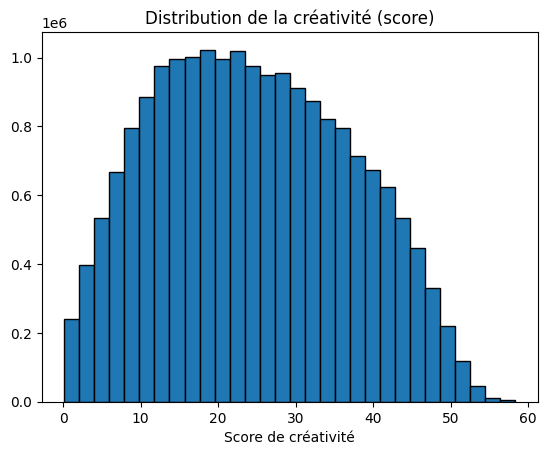

In [48]:
plt.hist(data_c_pond['score'], bins=30, edgecolor='black')
plt.title("Distribution de la créativité (score)")
plt.xlabel('Score de créativité')
plt.show()

La distribution de score est une cloche, les valeurs sont centrées autour de la moyenne qui vaut environ 25 et forment une distribution quasi symétrique avec une très légère asymétrie à gauche. 

Dans la suite, l'analyse descriptive porte uniquement sur le lien entre la première variable de créativité creative_out et les autres variables. Le cas de la deuxième variable score sera traité notamment avec la régression linéaire en dernière partie. 

#### **3. Activités créatives et niveau socio-économique**

**3.1 Sans Pondération**

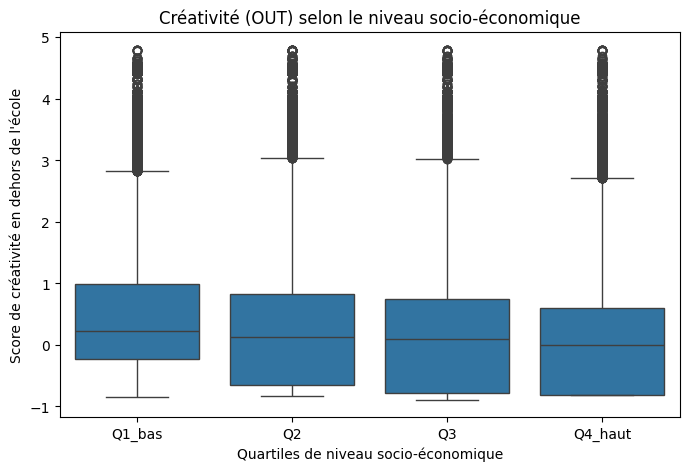

In [49]:
#Création des quartiles de niveau socio-économique
data_c['society_q'] = pd.qcut(data_c['society'], 4, labels=['Q1_bas', 'Q2', 'Q3', 'Q4_haut'])

#Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='society_q', y='creative_out', data=data_c)
plt.xlabel("Quartiles de niveau socio-économique")
plt.ylabel("Score de créativité en dehors de l'école")
plt.title("Créativité (OUT) selon le niveau socio-économique")
plt.show()


Contrairement à l'hypothèse intuitive, les élèves issus de milieux sociaux défavorisés (Q1) participent davantage à des activités créatives en dehors de l'école que les élèves issus de milieux favorisés. De plus, les élèves sont plus homogènes en terme de créativités à mesure que l'enfant est issus d'un milieu moins favorisé. 

Ce résultat contre-intuitif suggère que la rareté de ressources pourrait favoriser une créativité plus robuste et généralisée. Tandis que l'accès illimité crée des inégalités dans l'expression créative. Cela appuie l'hypothèse qu'un équilibre optimal entre rareté et accès, plutôt qu'un accès maximal, serait le plus favorable au développement de la pensée créative.

**3.2 Avec pondération**


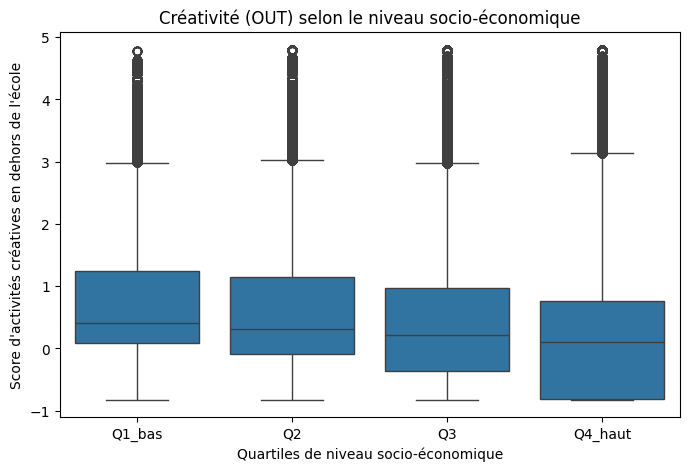

In [126]:
#Création des quartiles de niveau socio-économique
data_c_pond['society_q'] = pd.qcut(data_c_pond['society'], 4, labels=['Q1_bas', 'Q2', 'Q3', 'Q4_haut'])

#Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='society_q', y='creative_out', data=data_c_pond)
plt.xlabel("Quartiles de niveau socio-économique")
plt.ylabel("Score d'activités créatives en dehors de l'école")
plt.title("Créativité (OUT) selon le niveau socio-économique")
plt.show()


On constate la même corrélation que dans le cas sans pondération, plus le niveau socio-économique augmente, plus la créativité au sens de *creative_ou* diminue. 

La principale différence se trouve dans les valeurs de créativité qui se trouvent être plus élevées que dans le cas sans pondération pour les élèves dont le niveau socio-économique est le moins élevé. 

#### **4. Accès aux ressources numériques à domicile et activités créatives en dehors de l'école**

**4.1 sans pondération**

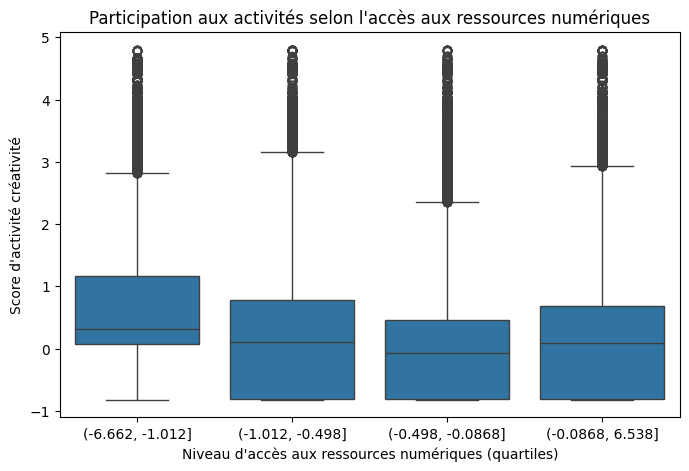

In [127]:
#Boxplot créativité / ressources numériques
plt.figure(figsize=(8,5))
sns.boxplot(x=pd.qcut(data_c['digital_home'], 4),
            y=data_c['creative_out'])
plt.xlabel("Niveau d'accès aux ressources numériques (quartiles)")
plt.ylabel("Score d'activité créativité")
plt.title("Participation aux activités selon l'accès aux ressources numériques")
plt.show()


Les résultats qui lient la participation aux activités créatives en dehors de l'école et l'accès aux ressources technologiques soutiennent les conclusions faites précédemment. Le même schéma que précédemment a lieu, le niveau d'accès aux ressources numériques étant probablement corrélé au cadre socio-économique de l'élève, cela est cohérent. Les élèves disposant d'un accès réduit aux ressources numériques participent davantage aux activités créatives en dehors de l'école que ceux ayant un accès très élevé. Surtout, les élèves de premier quartile participent systématiquement davantage que la moyenne internationale aux activités créatives avec un score de créativité positif. 

En revanche, le groupe à fort accès numérique présente une hétérogénéité marquée avec une partie importante des élèves en dessous de la moyenne internationale. 

Cela suggère que la contrainte numérique génère une créativité robuste. L'abondance numérique ne se traduit pas nécessairement par une participation plus accrue aux activités créatives, renforçant l'hypothèse d'un seuil optimal d'accès à l'information. 


**4.2 Avec pondération**

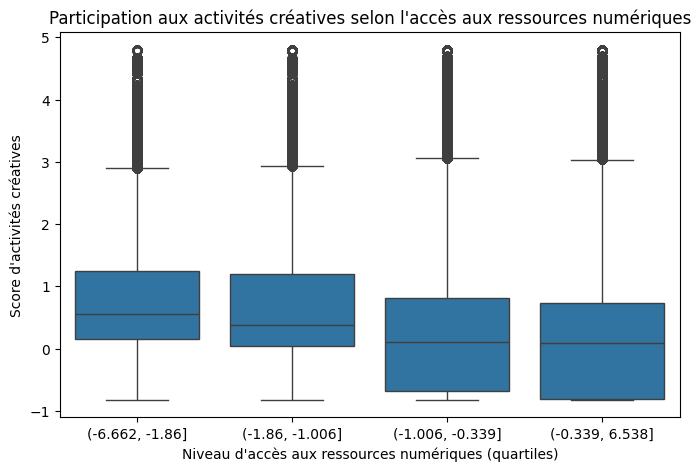

In [129]:
#Boxplot créativité / ressources numériques
plt.figure(figsize=(8,5))
sns.boxplot(x=pd.qcut(data_c_pond['digital_home'], 4),
            y=data_c_pond['creative_out'])
plt.xlabel("Niveau d'accès aux ressources numériques (quartiles)")
plt.ylabel("Score d'activités créatives")
plt.title("Participation aux activités créatives selon l'accès aux ressources numériques")
plt.show()


On constate une certaine différence au niveau des deux premiers quartiles qui ont vu leur score de participation aux activités créatives augmenter. On voit notamment que le groupe associé à la médiane a vu sa créativité (out) se concentrer. 

#### **5. Participation aux activités créativité à l’extérieur et exposition mathématique**

**5.1 Sans pondération**

In [39]:
#Corrélation
corr = data_c[['creative_out', 'math_reasoning']].corr()
print(corr)

                creative_out  math_reasoning
creative_out        1.000000        0.138658
math_reasoning      0.138658        1.000000


La participation aux activités créatives en dehors de l'école et l'exposition à des tâches mathématiques sont corrélées positivement. Même si cette corrélation est faible, cela suggère que les capacités cognitives contribuent à davantage de participation aux activités créatives mais ne sont pas l'unique déterminant de cette dernière. 

/tmp/ipykernel_104082/3570492093.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_crea = data_c.groupby('math_bin')['creative_out'].mean().reset_index()


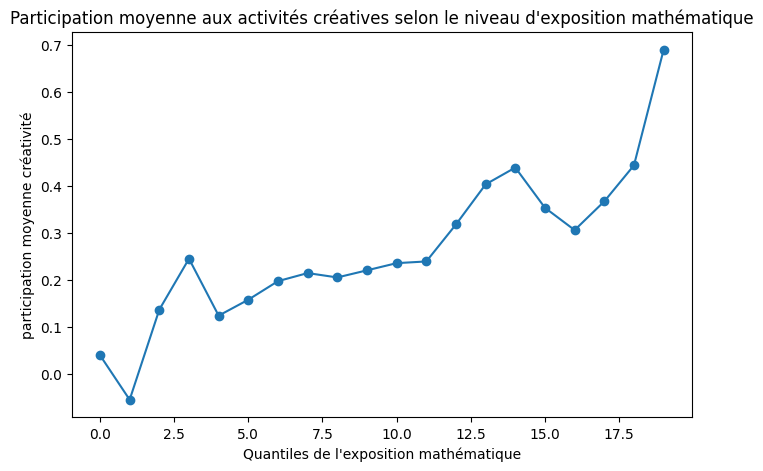

In [130]:
#Representation de la participation moyenne aux activités créatives selon quartiles math_reasoning
data_c['math_bin'] = pd.qcut(data_c['math_reasoning'], 20)

mean_crea = data_c.groupby('math_bin')['creative_out'].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(range(len(mean_crea)), mean_crea['creative_out'], marker='o')
plt.xlabel("Quantiles de l'exposition mathématique")
plt.ylabel("participation moyenne créativité")
plt.title("Participation moyenne aux activités créatives selon le niveau d'exposition mathématique")
plt.show()


Contrairement à ce que l'on avait pu observer précédemment avec les ressources matérielles qui dépendent davantage des moyens financiers du ménage de l'élève, une hausse de l'exposition mathématique et donc des capacités cognitives augmente le score de créativité moyen. 

Cependant, bien que la créativité augmente avec l'exposition aux tâches mathématiques, cette relation ne remet pas en cause l'hypothèse d'un équilibre optimal entre accès à l'information et rareté. 

**5.2 Avec pondération**

In [52]:
#Corrélation
corr = data_c_pond[['creative_out', 'math_reasoning']].corr()
print(corr)

                creative_out  math_reasoning
creative_out        1.000000        0.152331
math_reasoning      0.152331        1.000000


/tmp/ipykernel_104082/1637776572.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_crea = data_c_pond.groupby('math_bin')['creative_out'].mean().reset_index()


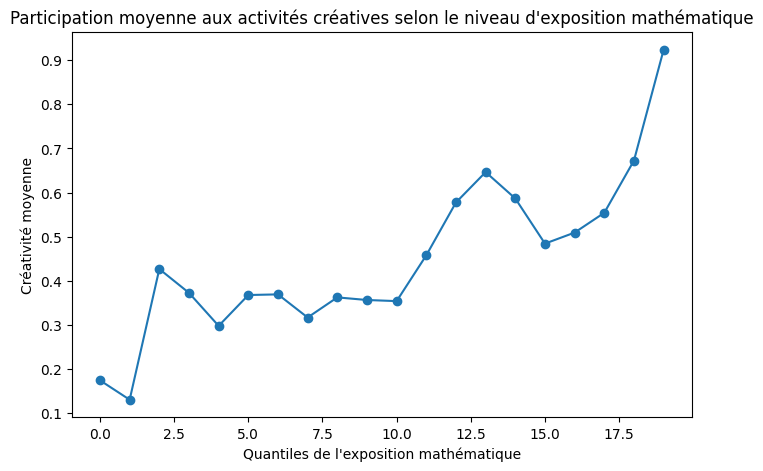

In [131]:
#Representation de la participation moyenne aux activités créatives selon quartiles math_reasoning
data_c_pond['math_bin'] = pd.qcut(data_c_pond['math_reasoning'], 20)

mean_crea = data_c_pond.groupby('math_bin')['creative_out'].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(range(len(mean_crea)), mean_crea['creative_out'], marker='o')
plt.xlabel("Quantiles de l'exposition mathématique")
plt.ylabel("Créativité moyenne")
plt.title("Participation moyenne aux activités créatives selon le niveau d'exposition mathématique")
plt.show()


On voit que le graphique est assez similaire ce qui est cohérent puisque les corrélations entre ces deux variables n'ont quasiment pas changé. 

#### **6. Distribution des variables**

**6.1 Sans pondération**

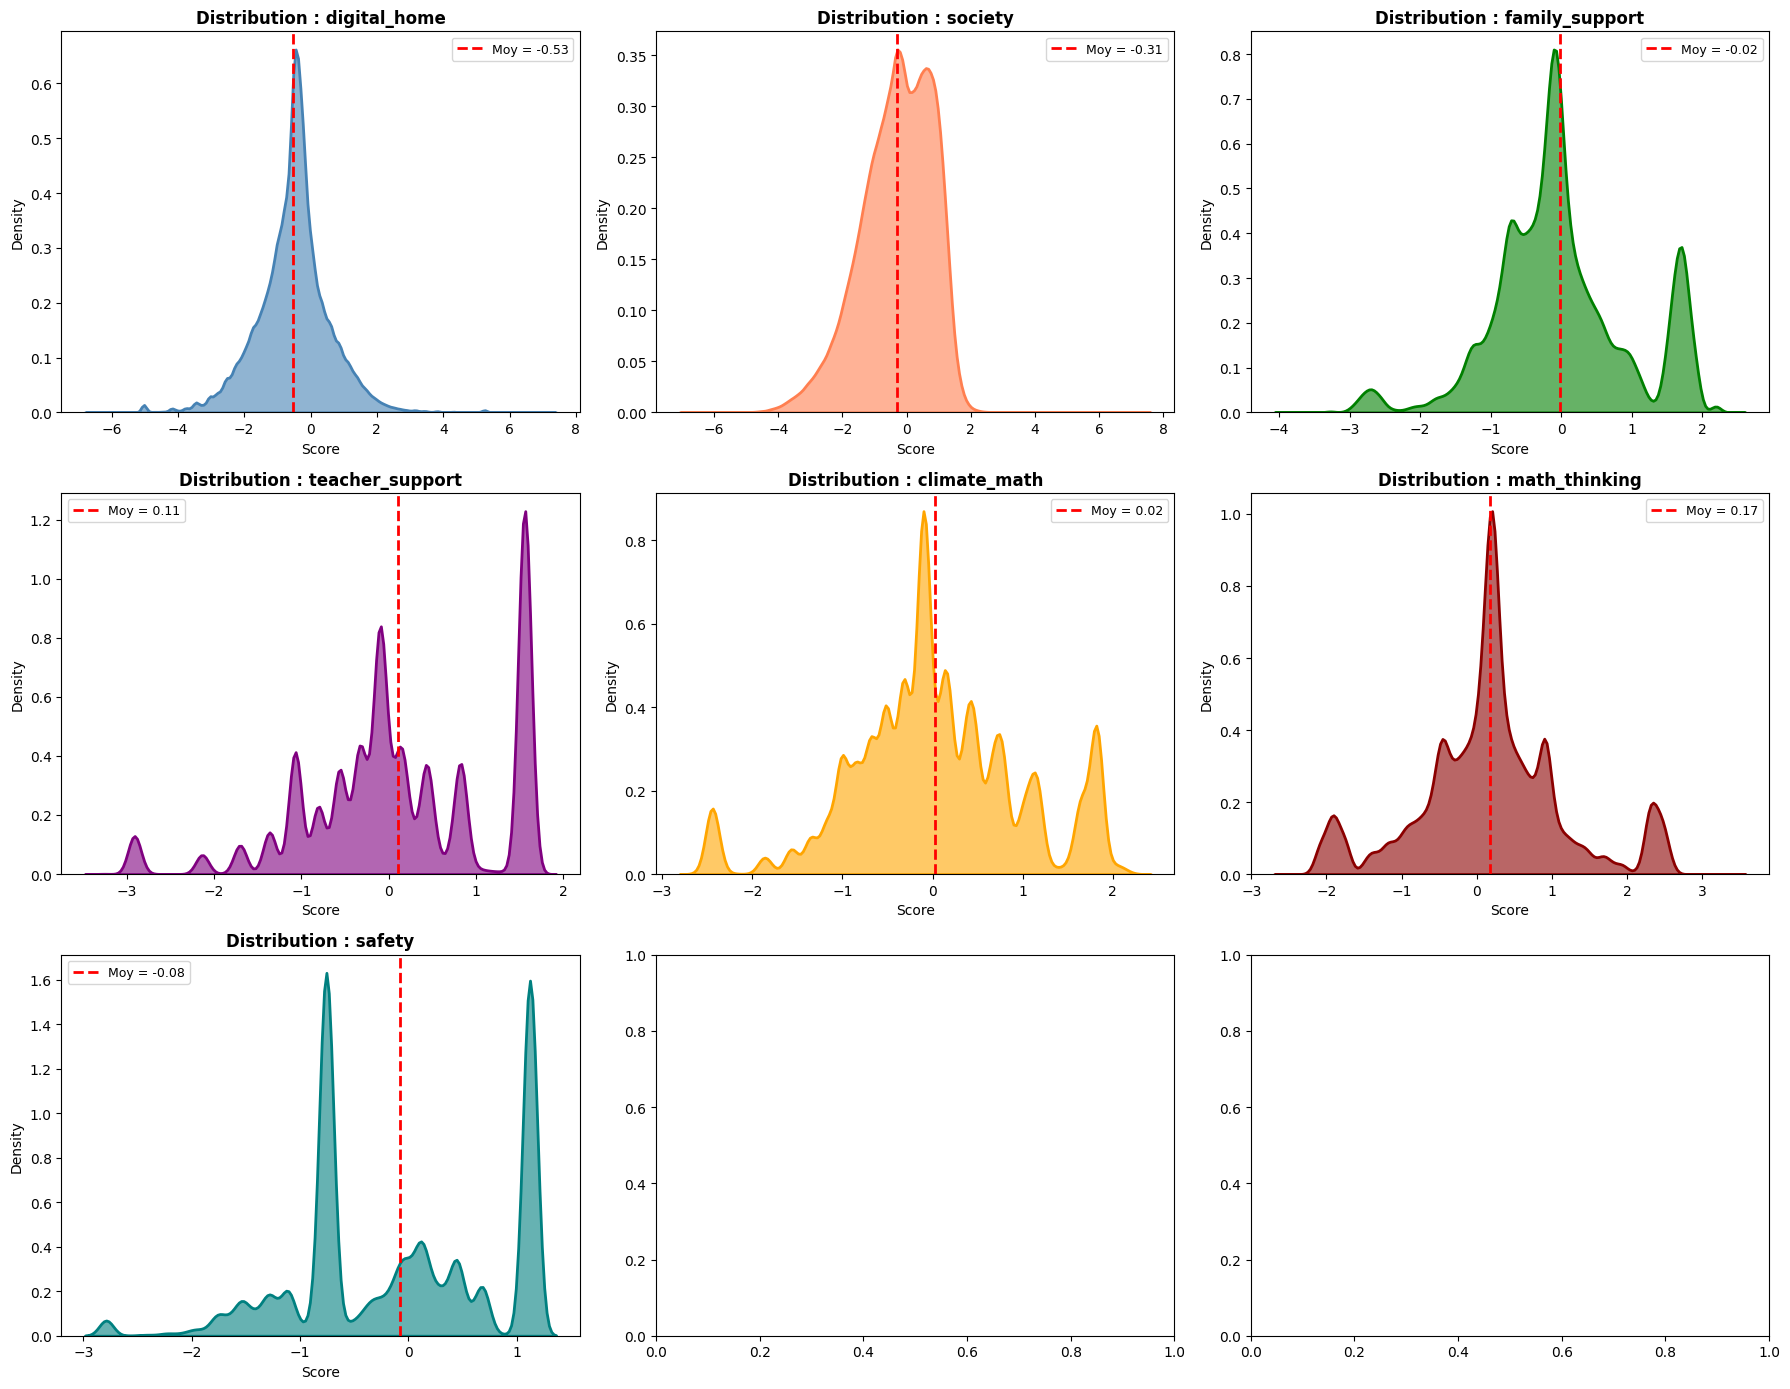

In [41]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

plot_vars = ['digital_home', 'society',
             'family_support', 'teacher_support', 'climate_math', 
             'math_thinking', 'safety']
colors = ['steelblue', 'coral', 'green', 'purple', 
          'orange', 'darkred', 'teal', 'navy', 'magenta']

for idx, (var, color) in enumerate(zip(plot_vars, colors)):
    if var in data_c.columns:
        data_var = data_c[var]
        if len(data_var) > 0:
            sns.kdeplot(data=data_var, ax=axes[idx], 
                       fill=True, color=color, alpha=0.6, linewidth=2)
            mean_val = data_var.mean()
            axes[idx].axvline(mean_val, color='red', 
                            linestyle='--', linewidth=2, label=f'Moy = {mean_val:.2f}')
            axes[idx].set_title(f'Distribution : {var}', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel('Score')
            axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.show()

Le sentiment de sécurité à l'école semble opposer 2 populations : l'une se sentant globalement en sécurité et l'autre beaucoup moins. 
De même pour le soutient pédagogique qui est hétérogène avec un ensemble d'élèves assez élevé qui déclare bénéficier d'un accompagnement très élevé. 
La distribution de l'accès au numérique est très concentrée et décalée à gauche, les élèves de notre échantillon ont globalement un faible accès aux technologies numériques. On retrouve une distribution similaire pour le cadre socio-économique et culturel. 
Le soutient familial, bien que centré en 0 révèle des situations contrastées.
La qualité du climat en classe de mathématique et la qualité pédagogique de l'enseignement présentent une variabilité significative, la majorité des élèves se situant autour d'un niveau intermédiaire. 

La forme des distributions indique que les effets de l'accès à l'information, du soutient éducatif, du climat scolaire et de la sécurité sur la créativité sont susceptibles d'être non linéaire. Ceci renforce l'hypothèse d'un point d'équilibre optimal dans le développement de la pensée créative.


**6.2 Avec pondération**

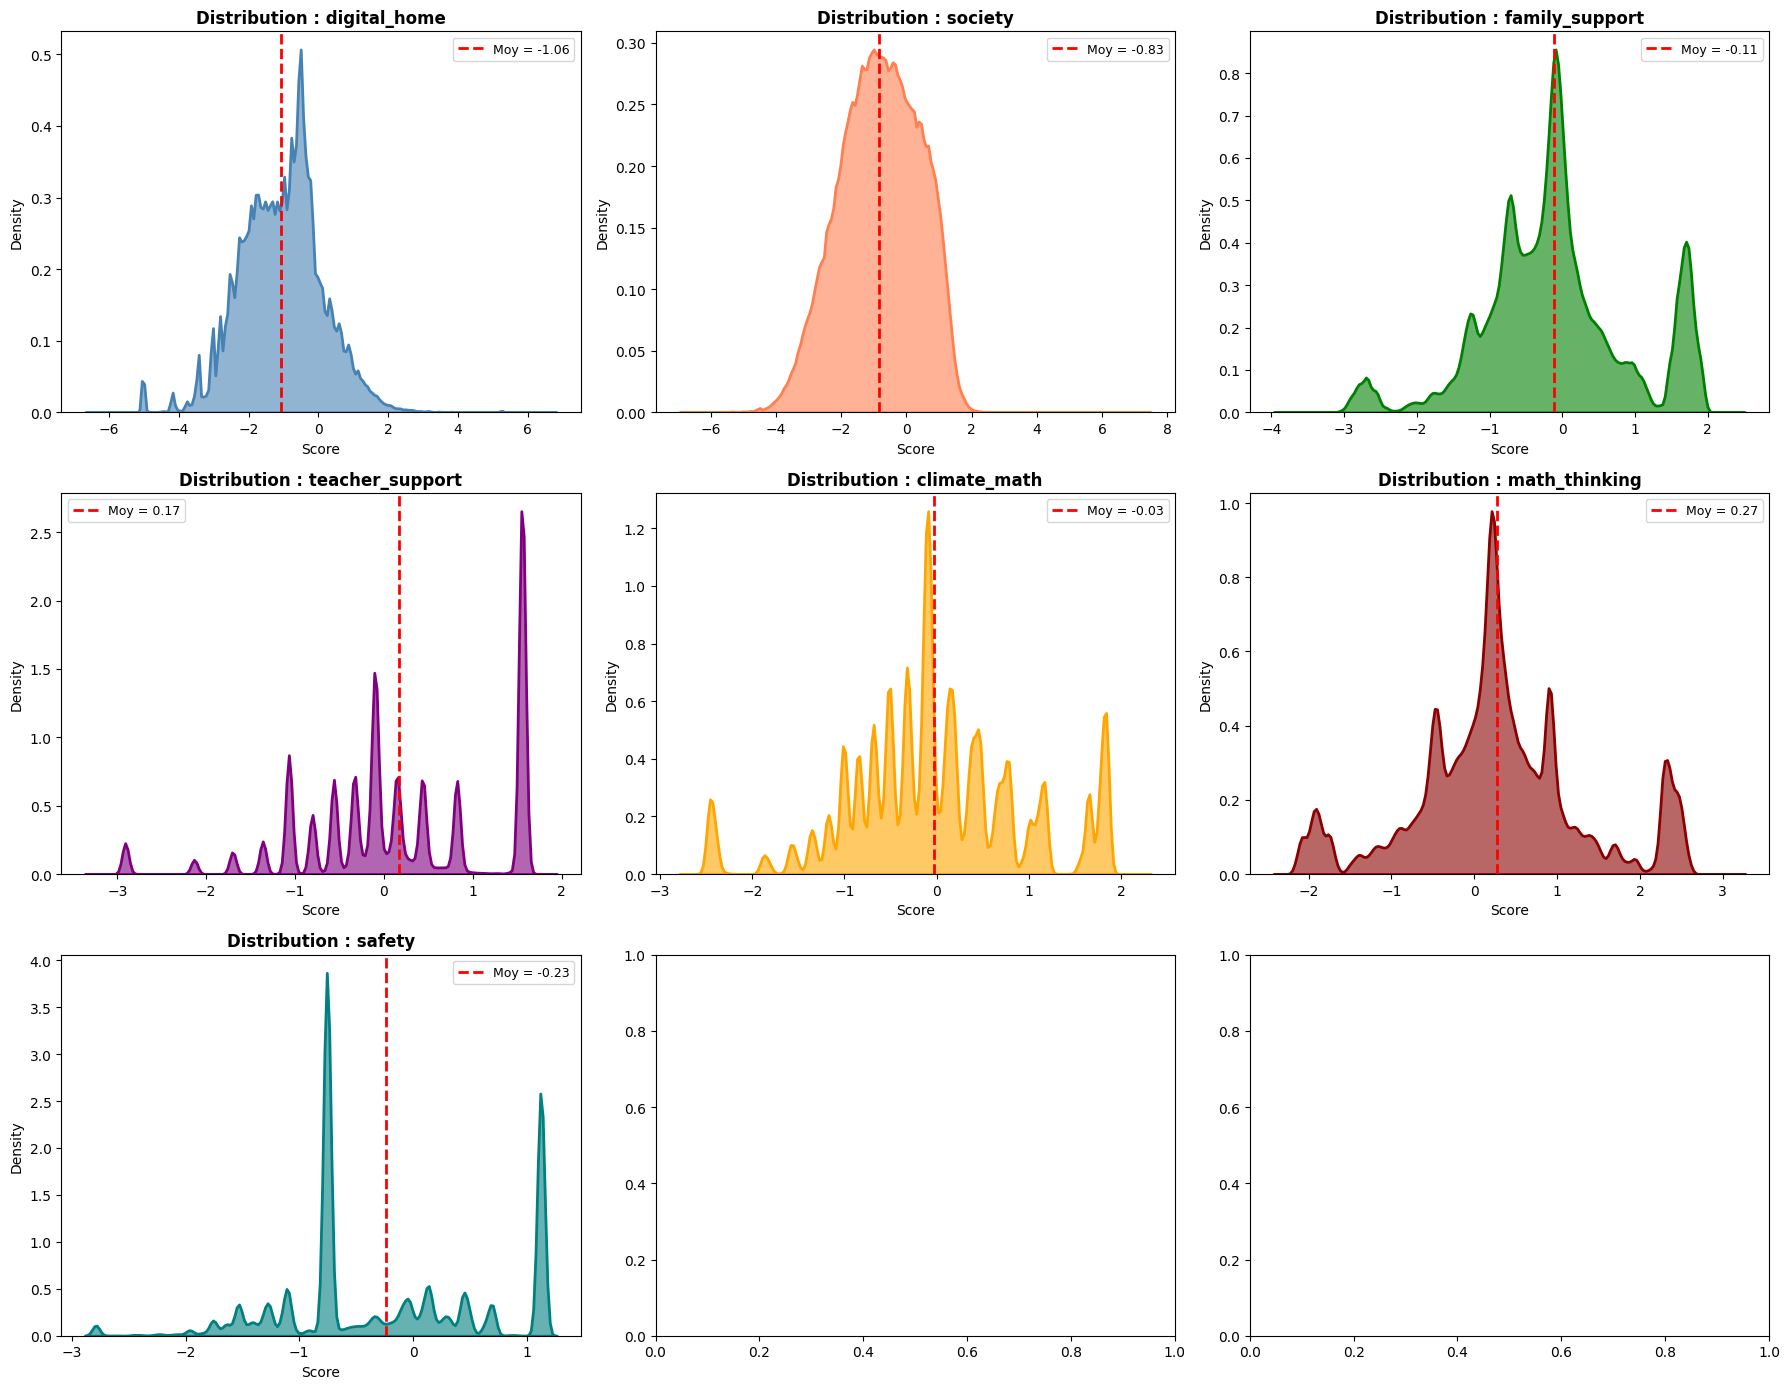

In [54]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

plot_vars = ['digital_home', 'society',
             'family_support', 'teacher_support', 'climate_math', 
             'math_thinking', 'safety']
colors = ['steelblue', 'coral', 'green', 'purple', 
          'orange', 'darkred', 'teal', 'navy', 'magenta']

for idx, (var, color) in enumerate(zip(plot_vars, colors)):
    if var in data_c_pond.columns:
        data_var = data_c_pond[var]
        if len(data_var) > 0:
            sns.kdeplot(data=data_var, ax=axes[idx], 
                       fill=True, color=color, alpha=0.6, linewidth=2)
            mean_val = data_var.mean()
            axes[idx].axvline(mean_val, color='red', 
                            linestyle='--', linewidth=2, label=f'Moy = {mean_val:.2f}')
            axes[idx].set_title(f'Distribution : {var}', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel('Score')
            axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.show()

On voit que là encore les différences majeures avec le cas sans pondération réside au niveau des quatre variables *digital_home*, *teacher_support*, *safety* et *society*. La distribution de *digital_home* a perdu sa symétrie, on retrouve que la variable *society* a vu sa distribution décalée vers les basses valeurs avec notamment une asymétrie vers la gauche. La variable *safety* semble clairement s'être concentré autour de 2 valeurs : -0.8 et 1.1. Enfin, la variable *teacher_support* a également vu ses valeurs se concentrer autour d'un nombre réduit de valeurs (-0.8, -0.6 etc. ).

#### **7. Matrice de corrélation**

**7.1 Sans pondération**

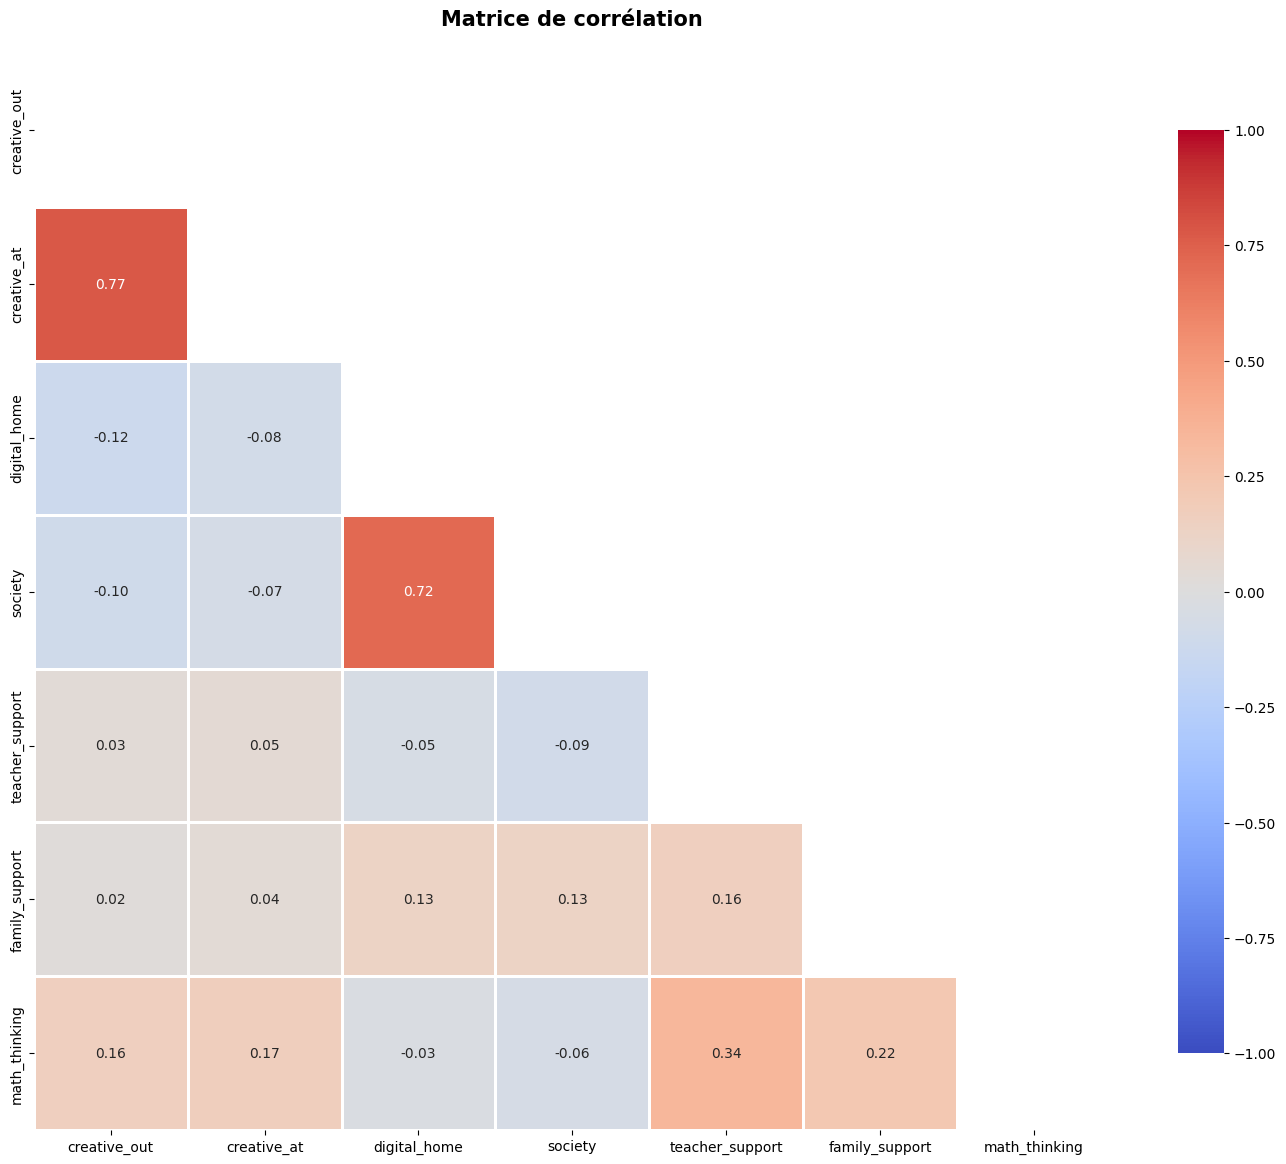

In [42]:
corr_vars = ['creative_out','creative_at','digital_home','ICTRES','society','teacher_support','family_support','math_thinking']

corr_vars = [v for v in corr_vars if v in data_c.columns]

corr_matrix = data_c[corr_vars].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation', 
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


La matrice de corrélation met en évidence une forte corrélation entre les 2 types de créativité (participation) suggérant que les élèves qui participent aux activités créatives à l'école poursuivent également ces activités en dehors du cadre scolaire. 

Les mesures du statut socio-économique et de la disponibilité de ressources numériques sont faiblement corrélées à la créativité ce qui pourrait laisser penser que les ressources disponibles ne suffisent pas à expliquer les différences de créativité entre les élèves. 

Le soutient familial et des professeurs sont encore plus faiblement corrélés à la pratique d'activités créatives. Cela suggère que leur relation avec la créativité n'est probablement pas linéaire. 

Enfin, une corrélation élevée entre le niveau socio-économique (society) et l'accès aux ressources numériques (digital_home) pourrait créer un problème de multicolinéarité qui nécessitera d'être considéré lors de la régression. L'accès aux ressources numériques étant grandement déterminé par le niveau socio-économique de l'élève.

L'ensemble de ces résultats suggère que le développement de la pensée créative résulte d'un équilibre complexe entre capacités intellectuelles, accès à l'information et environnement éducatif plutôt qu'une accumulation linéaire de ressources. 

**7.2 Avec pondération**

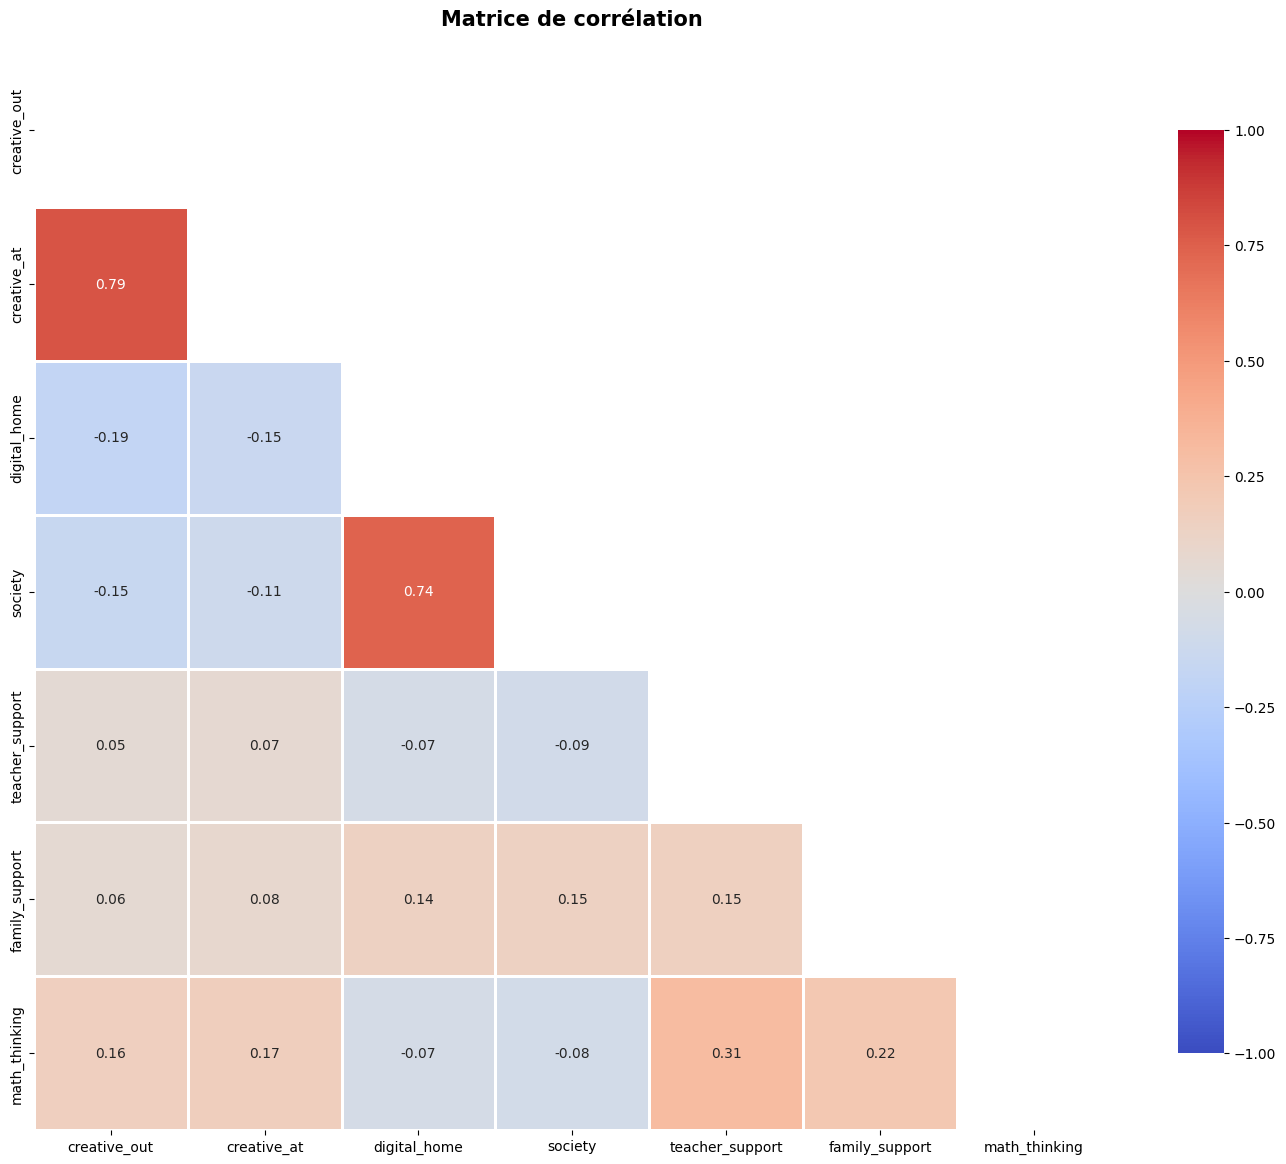

In [55]:
corr_vars = ['creative_out','creative_at','digital_home','ICTRES','society','teacher_support','family_support','math_thinking']

corr_vars = [v for v in corr_vars if v in data_c_pond.columns]

corr_matrix = data_c_pond[corr_vars].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8}, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation', 
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


On constate très peu de différences au niveau des corrélations. 

# **IV. Modélisation : régression linéaire**

L'objectif de cette partie est de réaliser plusieurs régressions linéaires sur les données avec imputation des données manquantes. Pour les deux prémiers régressions, qui utilisent `creative_out`comme variable expliquée, on utilise d'abord la régression OLS (sans pondération) et après la régression WLS (avec pondération), pour vérifier l'effet et la cohérence de la pondération. Pour ces deux régressions, on enlève la variable `creative_at` car elle est fortement corrélée avec `creative_out`.

In [ ]:
import statsmodels.api as sm
model = ols_model(data_c,'creative_out',drop_cols=['creative_at','math_bin','society_q','weight'])
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           creative_out   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     3983.
Date:                Mon, 29 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:22:09   Log-Likelihood:            -8.1021e+05
No. Observations:              613744   AIC:                         1.620e+06
Df Residuals:                  613728   BIC:                         1.621e+06
Df Model:                          15                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0727      0.003    -

Ce premier modèle utilise les moindres carrés ordinaires (OLS) pour estimer les facteurs associés aux activités créatives déclarées hors de l'école (`creative_out`). On utilise l'OLS sans pondération comme première approche exploratoire.

**Résultats clés :**

- **R² = 0.102** : Le modèle explique environ 10% de la variance, ce qui est modeste mais attendu pour des données comportementales auto-déclarées.

- **digital_home (β = -0.16)** : Un accès plus grand aux ressources numériques est associé à moins d'activités créatives hors école. Cela pourrait s'expliquer par un effet de substitution : les élèves bien équipés passent peut-être plus de temps sur des activités numériques passives (réseaux sociaux, streaming, jeux vidéo).

- **sport (β ≈ 0.03) et work (β ≈ 0.04)** : Les élèves qui pratiquent du sport ou qui travaillent déclarent davantage d'activités créatives. Cela suggère un profil d'élève "actif"  dehors de l'école.

- **math_reasoning et math_thinking (β > 0)** : L'exposition aux tâches mathématiques est positivement corrélée aux activités créatives, suggérant un lien entre le raisonnement mathématique et engagement créatif.

- **society (β ≈ 0)** : Le niveau socio-économique n'a pas d'effet significatif sur les activités créatives déclarées hors école.

- **safety (β < 0)** :  Résultat contre-intuitif - un niveau de sécurité plus élevé est associé à moins d'activités créatives. Cela pourrait indiquer que dans un environnement plus sécurisé, les élèves ont moins d'opportunités d'explorer des activités créatives.



Dans le cas précédent, on n'a pas considéré les poids de chaque occurrence. Maintenant, on va faire la régression en considérant les poids:

On passe maintenant à la déuxième partie: WLS avec `score` comme variable cible:



In [ ]:
data_c['weight'] = df['W_FSTUWT'] # variable poids

In [ ]:
model = wls_model(data_c,'creative_out','weight',drop_cols=['creative_at','math_bin','society_q','weight'])
print(model.summary())

                            WLS Regression Results                            
Dep. Variable:           creative_out   R-squared:                       0.130
Model:                            WLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     984.1
Date:                Mon, 29 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:48:02   Log-Likelihood:            -1.1374e+06
No. Observations:              613744   AIC:                         2.275e+06
Df Residuals:                  613728   BIC:                         2.275e+06
Df Model:                          15                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0016      0.006     

On reprend le modèle précédent en utilisant les moindres carrés pondérés (WLS) avec les poids d'enquête PISA (`W_FSTUWT`). Cette approche n'est pas la meilleure pour les données PISA, mais elle est peut être utile pour une première approche.

**Comparaison avec le modèle OLS :**

- Le R² augmente légèrement (0.130 vs 0.102), indiquant un meilleur ajustement avec la pondération.
- Les signes des coefficients restent cohérents, confirmant la robustesse des résultats.

**Résultats clés :**

- **digital_home (β = -0.152)** : L'effet négatif se confirme. Les élèves avec plus de ressources numériques déclarent moins d'activités créatives hors école.

- **gender (β = -0.012, p < 0.05)** : Contrairemet à la régression OLS, les filles déclarent moins d'activités créatives hors école.

- **society (β ≈ 0, non significatif)** : Le niveau socio-économique n'influence pas directement les activités créatives déclarées, toutes choses égales par ailleurs.

- **safety (β ≈ 0)** : L'effet de la sécurité n'est plus significatif.


**Conclusion intermédiaire :** Le WLS sera privilégié pour la suite car il respecte davantage le design d'enquête PISA.

Maintenant, on passe à la deuxième partie des régressions: WLS avec `score` comme cible.

In [ ]:
df_score = pd.merge(data_c, creat_df, on='id', how='inner') # on ajoute les scores
df_score.shape

NameError: name 'creat_df' is not defined

In [ ]:
model = wls_model(df_score,'score','weight',drop_cols=['math_bin','society_q','weight'])
print(model.summary())

                            WLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.357
Model:                            WLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     3291.
Date:                Mon, 29 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:12:02   Log-Likelihood:            -2.1408e+06
No. Observations:              499843   AIC:                         4.282e+06
Df Residuals:                  499825   BIC:                         4.282e+06
Df Model:                          17                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              30.7236      0.088    3

Ce modèle change de variable cible : on utilise maintenant le `score`. Cette variable mesure la performance cognitive au test, contrairement à `creative_out` qui mesurait des activités auto-déclarées.

**Résultats clés :**

- **R² = 0.357** : Le modèle explique environ un tiers de la variance du score, ce qui est nettement supérieur au modèle précédent.

- **society (β = 2.657)** : Le niveau socio-économique devient significatif: en effet, un niveau socio-économique plus élevé est associé à l'accès à une gamme de ressources qui peuvent augmenter le pensement créatif.

- **gender (β = 1.291)** : Les filles obtiennent en moyenne 2 points de plus que les garçons au test de pensée créative. 

- **digital_home (β = 2.128)** : Contrairement aux modèles précédents, l'accès aux ressources numériques est ici positivement associé au score. Cette inversion s'explique par la nature différente des variables : la participation à des activités créatives n'ont pas forcement un lien avec un pensement créatif, mêmes si on attendait le contraire.

- **creative_out (β = -1.922)** : Résultat inattendu : les activités créatives sont négativement associées au score. Peut-être que les activités créatives aident a construire un pensement plus diréctioné, c'est-à-dire moins créatif, car elles ont des objectifs, même si elles sont libres dans ce objectif.

- **work (β = -0.364) et household_care (β = -0.091)** : Le travail et les tâches ménagères sont négativement associés au score, suggérant que ces activités réduisent le temps disponible pour le développement du pensement créatif.

In [ ]:
df_score['digital_home2'] = df_score['digital_home']**2

In [ ]:
model = wls_model(df_score,'score','weight',drop_cols=['math_bin','society_q','weight'])
print(model.summary())

                            WLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.358
Model:                            WLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     3077.
Date:                Mon, 29 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:16:55   Log-Likelihood:            -2.1406e+06
No. Observations:              499843   AIC:                         4.281e+06
Df Residuals:                  499824   BIC:                         4.281e+06
Df Model:                          18                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              30.7660      0.088    3



**Résultats clés :**

- **digital_home (β = 1.865)** : Effet linéaire positif significatif
- **digital_home² (β = -0.132)** : Effet quadratique négatif significatif

Le coefficient négatif de `digital_home²` confirme l'hypothèse de **rendements décroissants** : les gains de créativité augmentent avec l'accès aux ressources numériques, mais à un rythme de plus en plus faible.

**Calcul du point optimal :**

Le score est maximisé quand la dérivée partielle s'annule :

$$\frac{\partial \text{score}}{\partial \text{digital\_home}} = \beta_1 + 2 \cdot \beta_2 \cdot \text{digital\_home} = 0$$

$$\text{digital\_home}^* = \frac{-\beta_1}{2 \cdot \beta_2} = \frac{-1.8647}{2 \times (-0.1322)} \approx 7.05$$

**Interprétation :** Le score de créativité est maximisé pour une valeur de `digital_home` d'environ **7.05** sur l'échelle standardisée PISA, qui est au-delà du rang de valeurs (-6.09,5.29)



# **V. Conclusion**

Notre hypothèse initiale était qu'il existe un point optimal d'accès aux ressources numériques maximisant la créativité des élèves. Les résultats confirment partiellement cette idée : le terme quadratique est négatif et significatif, indiquant bien des rendements décroissants.

Cependant, un résultat inattendu a émergé : l'effet de digital_home change de signe selon ce qu'on mesure. Il est négatif sur les activités créatives déclarées, mais positif sur le score au test. Plusieurs interprétations sont envisageables :

Les élèves bien équipés remplacent peut-être les activités créatives par des usages numériques passifs (réseaux sociaux, jeux vidéo).

Ce que les élèves déclarent comme "activités créatives" ne correspond pas forcément à ce que le test PISA mesure comme "pensée créative".

Sur le plan méthodologique, les modèles WLS avec pondération PISA ont donné de meilleurs résultats au sens du R², confirmant l'intérêt d'utiliser les poids d'enquête pour ce type de données.

Précisons que nous avons privilégié des analyses simples. Il aurait été possible d'inclure plus de variables ou d'utiliser des méthodes plus complexes, mais nous avons préféré interpréter nos résultats avec prudence plutôt que de multiplier les modèles.